<a href="https://colab.research.google.com/github/markmckeon11/Dissertation/blob/main/Final_Modelling_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import nbformat

# Load the notebook
notebook_path = '/content/drive/MyDrive/Colab Notebooks/Final_Modelling_XAI.ipynb'
with open(notebook_path, 'r', encoding='utf-8') as f:
    nb = nbformat.read(f, as_version=4)

# Remove problematic widget metadata
for cell in nb.cells:
    if 'metadata' in cell:
        if 'widgets' in cell['metadata']:
            del cell['metadata']['widgets']

# Save the cleaned notebook
cleaned_path = '/content/drive/MyDrive/Colab Notebooks/Final_Modelling_XAI.ipynb'
with open(cleaned_path, 'w', encoding='utf-8') as f:
    nbformat.write(nb, f)

print(f"Cleaned notebook saved to: {cleaned_path}")


Cleaned notebook saved to: /content/drive/MyDrive/Colab Notebooks/Final_Modelling_XAI.ipynb


In [7]:
import nbformat

# Load the notebook
notebook_path = '/content/drive/MyDrive/Colab Notebooks/Final_Modelling_XAI.ipynb'  # Update path
nb = nbformat.read(notebook_path, as_version=4)

# Remove 'widgets' from notebook-level metadata
if 'widgets' in nb['metadata']:
    del nb['metadata']['widgets']

# Also remove 'widgets' from individual cell metadata if present
for cell in nb.cells:
    if 'metadata' in cell and 'widgets' in cell['metadata']:
        del cell['metadata']['widgets']

# Save the cleaned notebook
clean_path = notebook_path.replace('.ipynb', '.ipynb')
nbformat.write(nb, clean_path)

print(f" Cleaned and saved to: {clean_path}")


 Cleaned and saved to: /content/drive/MyDrive/Colab Notebooks/Final_Modelling_XAI.ipynb


# Fine tuning of ClinicalBERT on MIMIC IV notes task of Predicting 30 Day readmissions

## Data Preparation

In [ ]:
import pandas as pd

notes_df = pd.read_csv('/content/drive/MyDrive/FYPData/mimiciv/processed_chunks/final_discharge.csv')

structured_df = pd.read_parquet('/content/drive/MyDrive/FYPData/final_data_ready_for_modelling.parquet')

# Filter notes to only include hadm_ids from structured (elderly) data
elderly_hadm_ids = structured_df['hadm_id'].unique()
filtered_notes = notes_df[notes_df['hadm_id'].isin(elderly_hadm_ids)].copy()

# Check result
print(f"Original notes shape : {notes_df.shape}")
print(f"Filtered notes shape : {filtered_notes.shape}")
print(filtered_notes[['hadm_id', 'text']].head())

# Save for ClinicalBERT fine-tuning
filtered_notes.to_csv('/content/drive/MyDrive/FYPData/notes_for_finetuning.csv', index=False)
print(" Filtered notes saved to: /content/drive/MyDrive/FYPData/notes_for_finetuning.csv")


Original notes shape : (331793, 3)
Filtered notes shape : (140865, 3)
     hadm_id                                               text
4   23052089   \nName:  ___                    Unit No:   __...
9   27897940   \nName:  ___               Unit No:   ___\n \...
18  29654838   \nName:  ___          Unit No:   ___\n \nAdmi...
19  26913865   \nName:  ___          Unit No:   ___\n \nAdmi...
20  24947999   \nName:  ___          Unit No:   ___\n \nAdmi...
 Filtered notes saved to: /content/drive/MyDrive/FYPData/notes_for_finetuning.csv


In [ ]:
import pandas as pd
import re

notes_path = "/content/drive/MyDrive/FYPData/notes_for_finetuning.csv"
notes_df = pd.read_csv(notes_path)

# Function to clean text
def clean_discharge_note(text):
    # Remove typical PHI patterns (Name, Unit No, Admission Date, etc.)
    text = re.sub(r'(Name:.*?Unit No:.*?)\n', '', text, flags=re.IGNORECASE | re.DOTALL)
    text = re.sub(r'Admission Date:.*?\n', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Discharge Date:.*?\n', '', text, flags=re.IGNORECASE)
    text = re.sub(r'Service:.*?\n', '', text, flags=re.IGNORECASE)

    # Remove extra spaces/newlines
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

# Apply cleaning
notes_df['clean_text'] = notes_df['text'].astype(str).apply(clean_discharge_note)

cleaned_notes_path = "/content/drive/MyDrive/FYPData/notes_cleaned.csv"
notes_df.to_csv(cleaned_notes_path, index=False)

print(" Cleaned notes saved to:", cleaned_notes_path)
print(" Sample cleaned text:\n", notes_df['clean_text'].iloc[0][:500])


 Cleaned notes saved to: /content/drive/MyDrive/FYPData/notes_cleaned.csv
 Sample cleaned text:
 Date of Birth: ___ Sex: M Allergies: No Known Allergies / Adverse Drug Reactions Attending: ___. Chief Complaint: Visual hallucinations Major Surgical or Invasive Procedure: N/A History of Present Illness: ___ male with ___ disease, dyslipidemia, and a history of prostate cancer (s/p prostatectomy) who was referred to the ED by his neurologist for worsening gait, falls, and visual hallucinations. The following history is taken from chart review: The patient was seen by his neurologist on ___ at 


In [ ]:
notes_df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_cleaned.csv")

structured_df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_data_ready_for_modelling.parquet")

label_df = structured_df[['hadm_id', 'readmitted_30d']].drop_duplicates()

# Merge on hadm_id
merged_df = pd.merge(notes_df, label_df, on='hadm_id', how='inner')

# Drop rows with missing clean_text or label
merged_df = merged_df.dropna(subset=['clean_text', 'readmitted_30d'])

final_ready_path = "/content/drive/MyDrive/FYPData/notes_ready_for_finetuning.csv"
merged_df.to_csv(final_ready_path, index=False)

print(" Merged and labeled notes saved to:", final_ready_path)
print(" Final shape:", merged_df.shape)
print(" Label distribution:\n", merged_df['readmitted_30d'].value_counts())


 Merged and labeled notes saved to: /content/drive/MyDrive/FYPData/notes_ready_for_finetuning.csv
 Final shape: (140865, 5)
 Label distribution:
 readmitted_30d
0    112714
1     28151
Name: count, dtype: int64


In [ ]:
df.head(10)

subject_id   hadm_id  \
0    10000084  23052089   
1    10000764  27897940   
2    10000980  29654838   
3    10000980  26913865   
4    10000980  24947999   
5    10000980  25242409   
6    10000980  25911675   
7    10000980  29659838   
8    10000980  20897796   
9    10001401  21544441   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [ ]:
import pandas as pd
import re

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning.csv")

# Define section headers to extract (based on clinical relevance)
SECTION_HEADERS = [
    r"history of present illness",
    r"brief hospital course|hospital course",
    r"acute/active issues",
    r"discharge diagnosis",
    r"discharge condition",
    r"discharge medications",
    r"follow[- ]?up instructions|follow[- ]?up plan",
]

# Clean & extract relevant sections
def extract_relevant_sections(text):
    text = text.lower()

    # Normalize spacing
    text = re.sub(r'\s+', ' ', text)

    # Capture relevant sections
    relevant_text = []
    for i, header in enumerate(SECTION_HEADERS):
        pattern = rf"{header}.*?(?=" + "|".join(SECTION_HEADERS[i+1:] + [r"$"]) + ")"
        match = re.search(pattern, text, re.DOTALL)
        if match:
            relevant_text.append(match.group())

    return " ".join(relevant_text).strip()

# Apply to dataset
df["extracted_text"] = df["text"].astype(str).apply(extract_relevant_sections)

# Additional cleaning
def clean_text(text):
    text = re.sub(r'\n+', ' ', text)  # remove newlines
    text = re.sub(r'[^a-z0-9.,;:!?()\-\'\"\s]', ' ', text)  # remove weird characters
    text = re.sub(r'\s+', ' ', text)  # collapse spaces
    return text.strip()

df["clean_text"] = df["extracted_text"].apply(clean_text)

df[["subject_id", "hadm_id", "clean_text", "readmitted_30d"]].to_csv(
    "/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv", index=False
)

print(" Done! Saved to: notes_ready_for_finetuning_extracted.csv")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Done! Saved to: notes_ready_for_finetuning_extracted.csv


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")

print("Number of rows:", len(df))
print("\nColumns:", df.columns.tolist())

print("\nMissing values:\n", df.isnull().sum())

# Length of notes (after cleaning)
df["note_length"] = df["clean_text"].astype(str).apply(len)
print("\nNote length stats:")
print(df["note_length"].describe())

# View very short notes
print("\nExamples of very short notes:")
display(df[df["note_length"] < 100][["clean_text", "readmitted_30d"]].head())

# View very long notes
print("\nExamples of long notes (near truncation risk):")
display(df[df["note_length"] > 4500][["clean_text", "readmitted_30d"]].head())

# Sample a note
print("\n--- Sample cleaned note ---\n")
print(df["clean_text"].iloc[0][:2000])  # print first 2000 characters of first note


Number of rows: 140865

Columns: ['subject_id', 'hadm_id', 'clean_text', 'readmitted_30d']

Missing values:
 subject_id        0
hadm_id           0
clean_text        5
readmitted_30d    0
dtype: int64

Note length stats:
count    140865.000000
mean       8903.819032
std        3597.110044
min           3.000000
25%        6556.000000
50%        8384.000000
75%       10650.000000
max       48758.000000
Name: note_length, dtype: float64

Examples of very short notes:


,clean_text,readmitted_30d
415,follow-up instructions,0
11157,NaN,0
11498,NaN,0
79848,brief hospital course discharge diagnosis: deceased discharge condition: deceased md completed by:,0
128820,NaN,0



Examples of long notes (near truncation risk):


clean_text  \
0                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               history of present illness: male with disease, dyslipidemia, and a history of prostate cancer (s p prostatectomy) who was referred to the ed by his neurologist for worsening gait, falls, and visual hallucinations. the following history is taken from chart review: the patient was seen by his neurologist on at which time he was noted to have visual hallucinations and worsening gait freezing. for his gait freezing, his mirapex was increased by 0.125 mg every week to a goal dose of 0.75 mg t.i.d. he successfully up-titrated the medicine to 0.75 0.625 0.625 but began to have visual hallucinations and confusion so on his neurologist recommended decreasing the dose to 0.625 tid. despite the changes to his mirapex, the patient's daughter has noted progressive gait stiffness and increased difficulty standing. this has resulted in difficulty with simply getting to the bathroom leading to episodes of incontinence. a ua performed on was reassuring. on the day of presentation to the hospital, the patient began to experience visual hallucinations of a motor cross race in his backyard. he subsequently had a fall while transferring from the couch to a chair. his wife was unable to get him off the floor. the fall was witnessed and there was no head strike. per the patient's wife, his gait has acutely worsened over the past 24 hours to the point where he has been unable to ambulate on his own. the patient's daughter called his neurologist who recommended presentation to the ed. in the ed, the patient was afebrile, hrs , normotensive, and spo2 100 ra. on exam he was noted to have cogwheeling of upper extremities and decrease strength. labs were remarkable for a negative urine and serum tox, na 132, k 5.8 (hemolyzed and no ekg changes), negative troponin, normal lfts, unremarkable cbc. chest xray showed no acute process and cth was reassuring. he was evaluated by neurology who recommended admission to medicine for failure to thrive, to continue the patient's home medications, and complete a toxo-metabolic workup. the patient was given his home pramipexole and pravastatin before he was admitted. on arrival to the floor, the patient is comfortable in bed. he is not accompanied by family on my interview. he knows that he is in the hospital and that it is . he is not sure why he is here and begins to tell me about a party in his house with a motor cross race in his backyard. when i asked him about his fall, he mentions that he has


--- Sample cleaned note ---

history of present illness: male with disease, dyslipidemia, and a history of prostate cancer (s p prostatectomy) who was referred to the ed by his neurologist for worsening gait, falls, and visual hallucinations. the following history is taken from chart review: the patient was seen by his neurologist on at which time he was noted to have visual hallucinations and worsening gait freezing. for his gait freezing, his mirapex was increased by 0.125 mg every week to a goal dose of 0.75 mg t.i.d. he successfully up-titrated the medicine to 0.75 0.625 0.625 but began to have visual hallucinations and confusion so on his neurologist recommended decreasing the dose to 0.625 tid. despite the changes to his mirapex, the patient's daughter has noted progressive gait stiffness and increased difficulty standing. this has resulted in difficulty with simply getting to the bathroom leading to episodes of incontinence. a ua performed on was reassuring. on the day of prese

## Sliding Window Chunking , Layer Freezing, and Efficient Processing - Best results

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")

# Check the shape and column names
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# Check for missing or short notes
missing = df["clean_text"].isna().sum()
too_short = (df["clean_text"].str.len() < 50).sum()
print(f"Missing notes: {missing}")
print(f"Notes shorter than 50 chars: {too_short}")

# Summary of note lengths
df["note_length"] = df["clean_text"].str.len()
print("\nSummary of note lengths:")
print(df["note_length"].describe())

# View a few random examples
sample = df.sample(3, random_state=42)
for i, row in sample.iterrows():
    print(f"\n=== Note {i} (HADM_ID: {row['hadm_id']}) ===")
    print(row["clean_text"][:1000])



Shape: (140865, 4)
Columns: ['subject_id', 'hadm_id', 'clean_text', 'readmitted_30d']
Missing notes: 5
Notes shorter than 50 chars: 1

Summary of note lengths:
count    140860.000000
mean       8904.134978
std        3596.782961
min          22.000000
25%        6556.000000
50%        8384.000000
75%       10650.000000
max       48758.000000
Name: note_length, dtype: float64

=== Note 56906 (HADM_ID: 21365753) ===
history of present illness: man with longstanding cad w p pci (angioplasty) in to right coronary artery at who presents with chest pain. he has been managed medically since then. he has been having worsening anginal symptoms with exertion over the past 6 months. he had a negative stress, but given high concern re: patient's persistent angina, he underwent a cardiac catheterization which showed severe 3vd. he is undergoing pre-op evaluation for cabg planned for . he had pfts done today as a part of the evaluation. during that testing he reports swallowing air and then develope

In [ ]:
sample_df = df.sample(5000, random_state=42)
sample_df["num_tokens"] = sample_df["clean_text"].apply(lambda x: len(tokenizer.tokenize(x)))
print("Max:", sample_df["num_tokens"].max())
print(">512:", (sample_df["num_tokens"] > 512).sum())


Max: 9675
>512: 4980


In [ ]:
!pip install -q datasets

In [ ]:
!pip install -q datasets transformers

In [ ]:
import pandas as pd
import numpy as np

hadm_ids_target = np.load("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_structured_leakfree.npy")

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")

matched_df = df[df["hadm_id"].isin(hadm_ids_target)]
print(f"Original notes size: {df.shape[0]}")
print(f"Matched notes size: {matched_df.shape[0]}")

matched_df.to_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv", index=False)

missing = set(hadm_ids_target) - set(matched_df["hadm_id"])
print(f"Missing hadm_ids not found in notes: {len(missing)}")


Original notes size: 140865
Matched notes size: 140818
Missing hadm_ids not found in notes: 0


In [ ]:
import pandas as pd
import numpy as np

structured_df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")

structured_hadm_ids = set(structured_df["hadm_id"].values)
print(f"Structured hadm_ids: {len(structured_hadm_ids)}")


Structured hadm_ids: 140818


In [ ]:
import pandas as pd

notes_df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv")
structured_df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")

# Extract hadm_ids
notes_hadm_ids = set(notes_df["hadm_id"].values)
structured_hadm_ids = set(structured_df["hadm_id"].values)

print(f"Notes hadm_ids: {len(notes_hadm_ids)}")
print(f"Structured hadm_ids: {len(structured_hadm_ids)}")

# Check missing IDs
missing_in_notes = structured_hadm_ids - notes_hadm_ids
missing_in_structured = notes_hadm_ids - structured_hadm_ids

print(f"HADM_IDs in structured but missing from notes: {len(missing_in_notes)}")
print(f"HADM_IDs in notes but missing from structured: {len(missing_in_structured)}")

if len(missing_in_notes) == 0 and len(missing_in_structured) == 0:
    print(" Perfect match! Notes and Structured data are fully aligned.")
else:
    print(" Mismatch detected!")


Notes hadm_ids: 140818
Structured hadm_ids: 140818
HADM_IDs in structured but missing from notes: 0
HADM_IDs in notes but missing from structured: 0
 Perfect match! Notes and Structured data are fully aligned.


In [ ]:
import re
import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm import tqdm
import random, gc
from datetime import datetime
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from datasets import Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import (
    AutoTokenizer, AutoModel, Trainer, TrainingArguments,
    DataCollatorWithPadding, EarlyStoppingCallback
)
from torch.utils.data import DataLoader
from transformers.modeling_outputs import SequenceClassifierOutput
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_extracted.csv")
df = df.dropna(subset=["clean_text"])
df = df.reset_index(drop=True)

SECTION_HEADERS = [
    r"history of present illness", r"brief hospital course|hospital course",
    r"acute/active issues", r"discharge diagnosis", r"discharge condition",
    r"discharge medications", r"follow[- ]?up instructions|follow[- ]?up plan",
]

def extract_relevant_sections(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\s+', ' ', text.lower())
    relevant = []
    for i, header in enumerate(SECTION_HEADERS):
        pattern = rf"{header}.*?(?=" + "|".join(SECTION_HEADERS[i+1:] + [r"$"]) + ")"
        match = re.search(pattern, text, re.DOTALL)
        if match:
            relevant.append(match.group())
    return " ".join(relevant).strip()

def clean_text(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-z0-9.,;:!?()\-\'\"\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df["extracted_text"] = df["clean_text"].apply(extract_relevant_sections)
df["clean_text_sectionfiltered"] = df["extracted_text"].apply(clean_text)

# Tokenize & Chunk
checkpoint = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def chunk_note_with_sliding_window(note, chunk_size=384, stride=256):
    tokens = tokenizer(note, truncation=False, padding=False)["input_ids"]
    chunks = []
    for i in range(0, len(tokens), stride):
        chunk = tokens[i:i + chunk_size]
        chunk += [tokenizer.pad_token_id] * (chunk_size - len(chunk))
        chunks.append(chunk)
        if i + chunk_size >= len(tokens):
            break
    return chunks

all_chunks, all_labels = [], []
for text, label in tqdm(zip(df["clean_text_sectionfiltered"], df["readmitted_30d"]), total=len(df), desc="Chunking"):
    chunks = chunk_note_with_sliding_window(text)
    all_chunks.extend(chunks)
    all_labels.extend([label] * len(chunks))

features = Features({"input_ids": [Value("int32")], "label": ClassLabel(num_classes=2)})
dataset = Dataset.from_dict({"input_ids": all_chunks, "label": all_labels}, features=features)
dataset.set_format(type="torch")

# Split
train_testvalid = dataset.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)
valid_test = train_testvalid["test"].train_test_split(test_size=0.5, stratify_by_column="label", seed=42)
dataset = DatasetDict(train=train_testvalid["train"], validation=valid_test["train"], test=valid_test["test"])

# Class Weights
y_train = np.array(dataset["train"]["label"])
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).cuda()

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(logits, targets)
        pt = torch.softmax(logits, dim=1)[range(len(targets)), targets]
        return ((1 - pt) ** self.gamma * ce).mean()

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits if isinstance(outputs, dict) else outputs[0]
        loss = FocalLoss(gamma=2.0, weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss


# Metrics
def compute_metrics(pred):
    logits, labels = pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs)
    }

# Model with Attention Pooling
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Parameter(torch.Tensor(hidden_size, 1))
        nn.init.xavier_uniform_(self.attn)

    def forward(self, hidden_states):
        scores = torch.matmul(hidden_states, self.attn).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        return torch.sum(weights.unsqueeze(-1) * hidden_states, dim=1)

class FinalClassifier(nn.Module):
    def __init__(self, model, hidden_size=768, num_labels=2):
        super().__init__()
        self.bert = model
        self.pool = AttentionPooling(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(outputs.last_hidden_state)
        logits = self.classifier(pooled)
        return SequenceClassifierOutput(logits=logits)

# Load BERT Base Model & Freeze Layers
base_model = AutoModel.from_pretrained(checkpoint)
for i in range(9):  # freeze first 9 layers
    for param in base_model.encoder.layer[i].parameters():
        param.requires_grad = False
base_model.gradient_checkpointing_enable()

gc.collect()
torch.cuda.empty_cache()

print("Current VRAM usage:")
!nvidia-smi

output_dir = "/content/drive/MyDrive/FYPData/clinicalbert_readmit_v1"  # clearer name for resumption
training_args = TrainingArguments(
    output_dir=output_dir,
    run_name="ClinicalBERT-AttentionPooling-Full",
    save_steps=500,
    logging_dir='/content/drive/MyDrive/FYPData/logs',
    logging_steps=200,
    num_train_epochs=2,
    per_device_train_batch_size=6,
    per_device_eval_batch_size=6,
    fp16=True,
    gradient_accumulation_steps=2,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    eval_accumulation_steps=64,
    dataloader_num_workers=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    save_total_limit=2,
    report_to=["none"],
    eval_strategy="epoch",
    save_strategy="epoch",
)

# Train
trainer = FocalTrainer(
    model=FinalClassifier(base_model),
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

test_logits = trainer.predict(dataset["test"]).predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1)[:, 1].numpy()
test_labels = dataset["test"]["label"]

np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_probs_full.npy", test_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels_full.npy", np.array(test_labels))

# Extract CLS Embeddings
bert_model = AutoModel.from_pretrained(training_args.output_dir).cuda()
bert_model.eval()

dataset["test"] = dataset["test"].remove_columns("label")
dataset["test"].set_format(type="torch", columns=["input_ids"])

def collate_fn(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])
    attention_mask = (input_ids != tokenizer.pad_token_id).long()
    return {"input_ids": input_ids.cuda(), "attention_mask": attention_mask.cuda()}

note_loader = DataLoader(dataset["test"], batch_size=32, collate_fn=collate_fn, pin_memory=True)

cls_embeddings = []
with torch.no_grad():
    for batch in tqdm(note_loader, desc="Extracting CLS embeddings"):
        outputs = bert_model(**batch)
        cls = outputs.last_hidden_state[:, 0, :]
        cls_embeddings.append(cls.cpu().numpy())

X_bert_cls = np.concatenate(cls_embeddings, axis=0)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_cls_embeddings_full.npy", X_bert_cls)
np.save("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_cls_full.npy", df.loc[dataset['test'].indices, "hadm_id"].values)

# Evaluation
y_true = np.array(test_labels)
y_prob = test_probs
y_pred = (y_prob >= 0.5).astype(int)

print("=== Classification Report")
print(classification_report(y_true, y_pred, digits=4))
print("=== Confusion Matrix")
print(confusion_matrix(y_true, y_pred))
print(f"AUROC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"PR AUC: {average_precision_score(y_true, y_prob):.4f}")

RocCurveDisplay.from_predictions(y_true, y_prob)
plt.title("ROC Curve - ClinicalBERT Sliding Window (Full)")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Chunking: 100%|██████████| 140860/140860 [17:10<00:00, 136.65it/s]


Current VRAM usage:
Wed Apr 23 23:09:42 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P0             26W /   70W |     104MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

<ipython-input-3-48210201b24b>:200: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Pr Auc
1,0.169500,0.167488,0.546343,0.391455,0.273943,0.685524,0.640736,0.329889
2,0.165500,0.168823,0.681853,0.374645,0.322066,0.447741,0.647808,0.340314


OSError: Error no file named pytorch_model.bin, model.safetensors, tf_model.h5, model.ckpt.index or flax_model.msgpack found in directory /content/drive/MyDrive/FYPData/clinicalbert_readmit_v1.

In [ ]:
import re
import numpy as np
import pandas as pd
import torch
from torch import nn
from tqdm import tqdm
import random, gc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from datasets import Dataset, DatasetDict, ClassLabel, Features, Value
from transformers import (
    AutoTokenizer, AutoModel, Trainer, TrainingArguments,
    DataCollatorWithPadding, EarlyStoppingCallback
)
import matplotlib.pyplot as plt
from transformers.modeling_outputs import SequenceClassifierOutput

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv")
df = df.reset_index(drop=True)

# Section Extraction and Cleaning
SECTION_HEADERS = [
    r"history of present illness", r"brief hospital course|hospital course",
    r"acute/active issues", r"discharge diagnosis", r"discharge condition",
    r"discharge medications", r"follow[- ]?up instructions|follow[- ]?up plan",
]

def extract_relevant_sections(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = re.sub(r'\s+', ' ', text.lower())
    relevant = []
    for i, header in enumerate(SECTION_HEADERS):
        pattern = rf"{header}.*?(?=" + "|".join(SECTION_HEADERS[i+1:] + [r"$"]) + ")"
        match = re.search(pattern, text, re.DOTALL)
        if match:
            relevant.append(match.group())
    return " ".join(relevant).strip()

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-z0-9.,;:!?()\-\'\"\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df["extracted_text"] = df["clean_text"].apply(extract_relevant_sections)
df["clean_text_sectionfiltered"] = df["extracted_text"].apply(clean_text)

# Tokenize and Chunk
checkpoint = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

def chunk_note_with_sliding_window(note, chunk_size=384, stride=256):
    if not isinstance(note, str) or note.strip() == "":
        tokens = []
    else:
        tokens = tokenizer(note, truncation=False, padding=False)["input_ids"]

    chunks = []
    for i in range(0, len(tokens), stride):
        chunk = tokens[i:i + chunk_size]
        chunk += [tokenizer.pad_token_id] * (chunk_size - len(chunk))
        chunks.append(chunk)
        if i + chunk_size >= len(tokens):
            break

    if not chunks:
        chunks.append([tokenizer.pad_token_id] * chunk_size)  # force at least one chunk if empty note

    return chunks

all_chunks, all_labels = [], []
for text, label in tqdm(zip(df["clean_text_sectionfiltered"], df["readmitted_30d"]), total=len(df), desc="Chunking"):
    chunks = chunk_note_with_sliding_window(text)
    all_chunks.extend(chunks)
    all_labels.extend([label] * len(chunks))

features = Features({"input_ids": [Value("int32")], "label": ClassLabel(num_classes=2)})
dataset = Dataset.from_dict({"input_ids": all_chunks, "label": all_labels}, features=features)
dataset.set_format(type="torch")

# Train/Validation/Test Split
train_testvalid = dataset.train_test_split(test_size=0.2, stratify_by_column="label", seed=42)
valid_test = train_testvalid["test"].train_test_split(test_size=0.5, stratify_by_column="label", seed=42)
dataset = DatasetDict(train=train_testvalid["train"], validation=valid_test["train"], test=valid_test["test"])

# Class Weights
y_train = np.array(dataset["train"]["label"])
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).cuda()

# Focal Loss and Trainer
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = nn.CrossEntropyLoss(weight=self.weight, reduction='none')(logits, targets)
        pt = torch.softmax(logits, dim=1)[range(len(targets)), targets]
        return ((1 - pt) ** self.gamma * ce).mean()

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits if isinstance(outputs, dict) else outputs[0]
        loss = FocalLoss(gamma=2.0, weight=class_weights)(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(pred):
    logits, labels = pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds),
        "precision": precision_score(labels, preds),
        "recall": recall_score(labels, preds),
        "roc_auc": roc_auc_score(labels, probs),
        "pr_auc": average_precision_score(labels, probs)
    }

# Model Definition
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Parameter(torch.Tensor(hidden_size, 1))
        nn.init.xavier_uniform_(self.attn)

    def forward(self, hidden_states):
        scores = torch.matmul(hidden_states, self.attn).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        return torch.sum(weights.unsqueeze(-1) * hidden_states, dim=1)

class FinalClassifier(nn.Module):
    def __init__(self, model, hidden_size=768, num_labels=2):
        super().__init__()
        self.bert = model
        self.pool = AttentionPooling(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(outputs.last_hidden_state)
        logits = self.classifier(pooled)
        return SequenceClassifierOutput(logits=logits)

# Load BERT Model & Freeze Layers
base_model = AutoModel.from_pretrained(checkpoint)
for i in range(9):  # Freeze first 9 layers
    for param in base_model.encoder.layer[i].parameters():
        param.requires_grad = False
base_model.gradient_checkpointing_enable()

gc.collect()
torch.cuda.empty_cache()

print("Current VRAM usage:")
!nvidia-smi

# Training Arguments
output_dir = "/content/drive/MyDrive/FYPData/clinicalbert_readmit_matched"
training_args = TrainingArguments(
    output_dir=output_dir,
    run_name="ClinicalBERT-AttentionPooling-Matched",
    save_steps=500,
    logging_dir='/content/drive/MyDrive/FYPData/logs',
    logging_steps=200,
    num_train_epochs=2,
    per_device_train_batch_size=6,
    per_device_eval_batch_size=6,
    fp16=True,
    gradient_accumulation_steps=2,
    warmup_steps=500,
    weight_decay=0.01,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    eval_accumulation_steps=64,
    dataloader_num_workers=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_f1",
    save_total_limit=2,
    report_to=["none"],
    eval_strategy="epoch",
    save_strategy="epoch",
)

# Train
trainer = FocalTrainer(
    model=FinalClassifier(base_model),
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["validation"],
    tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

# Save final best model manually
trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print(" Saved final model and tokenizer manually too!")

test_logits = trainer.predict(dataset["test"]).predictions
test_probs = torch.softmax(torch.tensor(test_logits), dim=1)[:, 1].numpy()
test_labels = dataset["test"]["label"]

np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_probs_matched.npy", test_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels_matched.npy", np.array(test_labels))

print(" Saved ClinicalBERT test probs and labels successfully!")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Chunking: 100%|██████████| 140818/140818 [16:51<00:00, 139.15it/s]


Current VRAM usage:
Sun Apr 27 21:07:49 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P0             27W /   70W |     104MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------------

<ipython-input-2-41c24dbaf966>:208: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `FocalTrainer.__init__`. Use `processing_class` instead.
  trainer = FocalTrainer(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Pr Auc
1,0.167300,0.165971,0.626477,0.387316,0.297559,0.554612,0.643936,0.337210


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Roc Auc,Pr Auc
1,0.165000,0.168524,0.658607,0.390777,0.315083,0.514339,0.653114,0.348762


 Saved final model and tokenizer manually too!


 Saved ClinicalBERT test probs and labels successfully!


In [ ]:
# Save full FinalClassifier model manually
save_path = "/content/drive/MyDrive/FYPData/clinicalbert_full_finalclassifier_matched"

import os
os.makedirs(save_path, exist_ok=True)

# Save model weights
torch.save(trainer.model.state_dict(), f"{save_path}/pytorch_model.bin")

# Also save the tokenizer
tokenizer.save_pretrained(save_path)

print(f" Saved full model and tokenizer to {save_path}")


 Saved full model and tokenizer to /content/drive/MyDrive/FYPData/clinicalbert_full_finalclassifier_matched


In [ ]:
import os

save_path = "/content/drive/MyDrive/FYPData/clinicalbert_full_finalclassifier_matched"
os.listdir(save_path)


['pytorch_model.bin',
 'tokenizer_config.json',
 'special_tokens_map.json',
 'vocab.txt',
 'tokenizer.json']

## Manually saving correctly aligned embeddings to match structured shape

In [ ]:
import re
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
from torch import nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig
from datasets import Dataset
from transformers.modeling_outputs import SequenceClassifierOutput

# Preprocess notes
df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv")
df = df.dropna(subset=["clean_text"]).reset_index(drop=True)

SECTION_HEADERS = [
    r"history of present illness", r"brief hospital course|hospital course",
    r"acute/active issues", r"discharge diagnosis", r"discharge condition",
    r"discharge medications", r"follow[- ]?up instructions|follow[- ]?up plan",
]

def extract_relevant_sections(text):
    if not isinstance(text, str): return ""
    text = re.sub(r'\s+', ' ', text.lower())
    relevant = []
    for i, header in enumerate(SECTION_HEADERS):
        pattern = rf"{header}.*?(?=" + "|".join(SECTION_HEADERS[i+1:] + [r"$"]) + ")"
        match = re.search(pattern, text, re.DOTALL)
        if match: relevant.append(match.group())
    return " ".join(relevant).strip()

def clean_text(text):
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-z0-9.,;:!?()\-\'\"\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df["extracted_text"] = df["clean_text"].apply(extract_relevant_sections)
df["clean_text_sectionfiltered"] = df["extracted_text"].apply(clean_text)

# Tokenizer and chunking
tokenizer = AutoTokenizer.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")

def chunk_note_with_sliding_window(note, chunk_size=384, stride=256):
    tokens = tokenizer(note, truncation=False, padding=False)["input_ids"]
    chunks = []
    for i in range(0, len(tokens), stride):
        chunk = tokens[i:i + chunk_size]
        chunk += [tokenizer.pad_token_id] * (chunk_size - len(chunk))
        chunks.append(chunk)
        if i + chunk_size >= len(tokens): break
    return chunks

all_chunks = []
for text in tqdm(df["clean_text_sectionfiltered"], desc="Chunking"):
    all_chunks.extend(chunk_note_with_sliding_window(text))

dataset = Dataset.from_dict({"input_ids": all_chunks})
dataset.set_format(type="torch")

# Attention Pooling Layer
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.attn = nn.Parameter(torch.Tensor(hidden_size, 1))
        nn.init.xavier_uniform_(self.attn)

    def forward(self, hidden_states):
        scores = torch.matmul(hidden_states, self.attn).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        return torch.sum(weights.unsqueeze(-1) * hidden_states, dim=1)

# FinalClassifier (Returns pooled embedding only)
class FinalClassifier(nn.Module):
    def __init__(self, model, hidden_size=768):
        super().__init__()
        self.bert = model
        self.pool = AttentionPooling(hidden_size)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(outputs.last_hidden_state)
        return pooled

# Load fine-tuned encoder with correct config
base_path = "/content/drive/MyDrive/FYPData/clinicalbert_readmit_matched"
config = AutoConfig.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
base_model = AutoModel.from_pretrained(base_path, config=config)
model = FinalClassifier(model=base_model, hidden_size=768).eval().cuda()

# DataLoader
def collate_fn(batch):
    input_ids = torch.stack([x["input_ids"] for x in batch])
    attention_mask = (input_ids != tokenizer.pad_token_id).long()
    return {"input_ids": input_ids.cuda(), "attention_mask": attention_mask.cuda()}

dataloader = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

# Extract attention-pooled CLS embeddings
cls_embeddings = []
with torch.no_grad():
    for batch in tqdm(dataloader, desc="Extracting CLS Embeddings"):
        pooled = model(batch["input_ids"], batch["attention_mask"])
        cls_embeddings.append(pooled.cpu().numpy())

X_cls = np.concatenate(cls_embeddings, axis=0)
print(" Extracted CLS shape:", X_cls.shape)

# Save embeddings
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_epoch1.npy", X_cls)

# Save aligned hadm_ids
hadm_ids_per_chunk = []
for text, hadm_id in zip(df["clean_text_sectionfiltered"], df["hadm_id"]):
    chunks = chunk_note_with_sliding_window(text)
    hadm_ids_per_chunk.extend([hadm_id] * len(chunks))

test_size = len(dataset)
test_hadm_ids = hadm_ids_per_chunk[-test_size:]
np.save("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_epoch1.npy", np.array(test_hadm_ids))

print(" Saved final attention-pooled CLS embeddings and aligned HADM_IDs.")



Extracting CLS Embeddings: 100%|██████████| 43049/43049 [7:57:27<00:00,  1.50it/s]


 Extracted CLS shape: (1377561, 768)
 Saved final attention-pooled CLS embeddings and aligned HADM_IDs.


In [ ]:
import numpy as np
import pandas as pd

X_cls = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_epoch1.npy")
hadm_ids = np.load("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_epoch1.npy")

df = pd.DataFrame(X_cls)
df["hadm_id"] = hadm_ids

# Group by hadm_id and take mean of the embeddings
X_cls_mean = df.groupby("hadm_id").mean().reset_index()

# Extract back
hadm_ids_cls_mean = X_cls_mean["hadm_id"].values
X_cls_mean = X_cls_mean.drop(columns=["hadm_id"]).values

print(f"New X_cls shape after pooling: {X_cls_mean.shape}")
print(f"New hadm_ids shape: {hadm_ids_cls_mean.shape}")

np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_mean.npy", X_cls_mean)
np.save("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_mean.npy", hadm_ids_cls_mean)


New X_cls shape after pooling: (140818, 768)
New hadm_ids shape: (140818,)


In [ ]:
import numpy as np
import pandas as pd

filtered_df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_matched_to_notes.parquet")
X_cls = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_mean.npy")
hadm_ids_cls = np.load("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_mean.npy")

# Set index for fast lookup
structured_indexed = filtered_df.set_index("hadm_id")

# Create existence mask
exist_mask = np.isin(hadm_ids_cls, structured_indexed.index)

# Apply mask
X_cls_aligned = X_cls[exist_mask]
hadm_ids_cls_aligned = hadm_ids_cls[exist_mask]

# Align structured features
aligned_structured = structured_indexed.loc[hadm_ids_cls_aligned].reset_index()

np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_aligned.npy", X_cls_aligned)
np.save("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_aligned.npy", hadm_ids_cls_aligned)
aligned_structured.to_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")

print(f"X_cls_aligned shape: {X_cls_aligned.shape}")
print(f"Aligned structured shape: {aligned_structured.shape}")
print(f"Aligned hadm_ids shape: {hadm_ids_cls_aligned.shape}")
print(" All aligned and saved using NEW attention-pooled embeddings!")


X_cls_aligned shape: (140818, 768)
Aligned structured shape: (140818, 139)
Aligned hadm_ids shape: (140818,)
 All aligned and saved using NEW attention-pooled embeddings!


In [ ]:
import numpy as np
import pandas as pd

X = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_aligned.npy")
hadm_ids = np.load("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_aligned.npy")
df_structured = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")

# Map hadm_ids to labels
hadm_to_label = dict(zip(df_structured['hadm_id'], df_structured['readmitted_30d']))
y = np.array([hadm_to_label[hadm_id] for hadm_id in hadm_ids])

print(f"Embeddings (X) shape: {X.shape}")
print(f"Labels (y) shape: {y.shape}")
print(f"HADM_IDs shape: {hadm_ids.shape}")

# Final X and y for clean MLP training
np.save("/content/drive/MyDrive/FYPData/Model_Results/X_attentionpooled_matched.npy", X)
np.save("/content/drive/MyDrive/FYPData/Model_Results/y_attentionpooled_matched.npy", y)

print("\n Saved:")
print("- /content/drive/MyDrive/FYPData/Model_Results/X_attentionpooled_matched.npy")
print("- /content/drive/MyDrive/FYPData/Model_Results/y_attentionpooled_matched.npy")
print("- (HADM_IDs were already aligned and saved)")


Embeddings (X) shape: (140818, 768)
Labels (y) shape: (140818,)
HADM_IDs shape: (140818,)

 Saved:
- /content/drive/MyDrive/FYPData/Model_Results/X_attentionpooled_matched.npy
- /content/drive/MyDrive/FYPData/Model_Results/y_attentionpooled_matched.npy
- (HADM_IDs were already aligned and saved)


In [ ]:
!pip install datasets


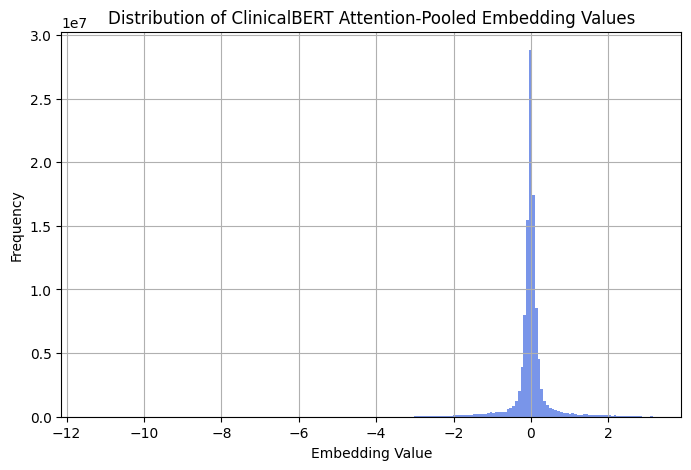

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X_cls_aligned = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_aligned.npy")

# Plot distribution of embedding values
plt.figure(figsize=(8,5))
plt.hist(X_cls_aligned.flatten(), bins=200, color='royalblue', alpha=0.7)
plt.title("Distribution of ClinicalBERT Attention-Pooled Embedding Values")
plt.xlabel("Embedding Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


/usr/local/lib/python3.11/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


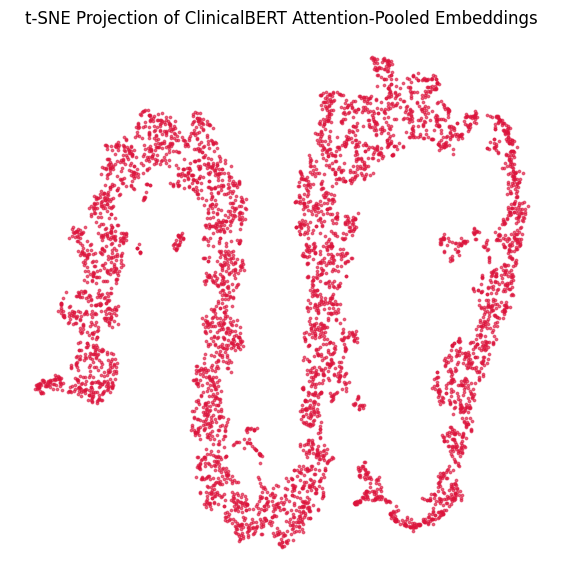

In [ ]:
from sklearn.manifold import TSNE

# Sample a subset
sample_idx = np.random.choice(len(X_cls_aligned), size=5000, replace=False)
X_sample = X_cls_aligned[sample_idx]

# Apply t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

# Plot
plt.figure(figsize=(7,7))
plt.scatter(X_tsne[:,0], X_tsne[:,1], s=3, alpha=0.6, color='crimson')
plt.title("t-SNE Projection of ClinicalBERT Attention-Pooled Embeddings")
plt.axis('off')
plt.show()


# Individual MLPs and Hybrid Models

## Fine-Tuned attention pooled embeddings MLP

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report, precision_recall_curve
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import json

X = np.load("/content/drive/MyDrive/FYPData/Model_Results/X_attentionpooled_matched.npy")
y = np.load("/content/drive/MyDrive/FYPData/Model_Results/y_attentionpooled_matched.npy")

# Split into Train/Val/Test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, stratify=y_temp, random_state=42)

# DataLoaders
def to_tensor(x, y): return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)
train_loader = DataLoader(TensorDataset(*to_tensor(X_train, y_train)), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(*to_tensor(X_val, y_val)), batch_size=64)
test_loader = DataLoader(TensorDataset(*to_tensor(X_test, y_test)), batch_size=64)

# Model
class ClinicalBERTMLP(nn.Module):
    def __init__(self, input_dim=768):
        super().__init__()
        self.model = nn.Sequential(
            nn.LayerNorm(input_dim),
            nn.BatchNorm1d(input_dim),
            nn.Linear(input_dim, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.BatchNorm1d(512),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.BatchNorm1d(256),
            nn.Linear(256, 2)
        )

    def forward(self, x): return self.model(x)

# Focal Loss
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = nn.CrossEntropyLoss(reduction='none')(logits, targets)
        pt = torch.softmax(logits, dim=1)[range(len(targets)), targets]
        if self.alpha is not None:
            at = self.alpha[targets]
            return (at * (1 - pt) ** self.gamma * ce).mean()
        return ((1 - pt) ** self.gamma * ce).mean()

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ClinicalBERTMLP().to(device)
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = FocalLoss(alpha=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# Evaluation Function
def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)
            preds += pred.cpu().tolist()
            probs += prob.cpu().tolist()
            labels += yb.cpu().tolist()
    return np.array(preds), np.array(probs), np.array(labels)

# Training Loop
save_path = "/content/drive/MyDrive/FYPData/Model_Results/mlp_clinicalbert_optimized_final.pt"
best_f1, counter, patience = 0, 0, 7

for epoch in range(1, 31):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    preds, probs, labels = evaluate(model, val_loader)
    f1 = f1_score(labels, preds)
    print(f"Epoch {epoch}: Loss={total_loss:.4f}, F1={f1:.4f}, Acc={accuracy_score(labels, preds):.4f}, "
          f"Prec={precision_score(labels, preds):.4f}, Rec={recall_score(labels, preds):.4f}, "
          f"AUROC={roc_auc_score(labels, probs):.4f}")

    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), save_path)
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Final Threshold Tuning on Validation
model.load_state_dict(torch.load(save_path))
_, val_probs, val_labels = evaluate(model, val_loader)
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
f1s = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1s)]

# Save Validation Outputs
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_final_probs.npy", val_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_final_labels.npy", val_labels)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_final_preds.npy", (val_probs >= best_thresh).astype(int))
with open("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_final_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

# Save Test Outputs for Late Fusion
_, test_probs, test_labels = evaluate(model, test_loader)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_probs.npy", test_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels.npy", test_labels)
np.save("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_preds.npy", (test_probs >= best_thresh).astype(int))

print(f"\nOptimal Threshold from Val: {best_thresh:.4f}")
print("Test AUROC :", roc_auc_score(test_labels, test_probs))
print("Test F1    :", f1_score(test_labels, test_probs >= best_thresh))
print("Test Prec  :", precision_score(test_labels, test_probs >= best_thresh))
print("Test Recall:", recall_score(test_labels, test_probs >= best_thresh))
print("\nTest Classification Report:\n", classification_report(test_labels, test_probs >= best_thresh, digits=4))




Epoch 1: Loss=286.8387, F1=0.4269, Acc=0.6723, Prec=0.3282, Rec=0.6105, AUROC=0.7173
Epoch 2: Loss=278.8803, F1=0.4478, Acc=0.7122, Prec=0.3633, Rec=0.5837, AUROC=0.7277
Epoch 3: Loss=278.4042, F1=0.4409, Acc=0.7241, Prec=0.3706, Rec=0.5442, AUROC=0.7261
Epoch 4: Loss=276.7698, F1=0.4406, Acc=0.6595, Prec=0.3281, Rec=0.6709, AUROC=0.7267
Epoch 5: Loss=275.8988, F1=0.4381, Acc=0.6449, Prec=0.3204, Rec=0.6922, AUROC=0.7291
Epoch 6: Loss=275.3528, F1=0.4422, Acc=0.6807, Prec=0.3398, Rec=0.6330, AUROC=0.7277
Epoch 7: Loss=274.4974, F1=0.4462, Acc=0.6863, Prec=0.3448, Rec=0.6322, AUROC=0.7300
Epoch 8: Loss=274.4350, F1=0.4476, Acc=0.6847, Prec=0.3445, Rec=0.6389, AUROC=0.7312
Epoch 9: Loss=274.1197, F1=0.4437, Acc=0.6599, Prec=0.3297, Rec=0.6784, AUROC=0.7310
Early stopping at epoch 9

Optimal Threshold from Val: 0.5033
Test AUROC : 0.7418024249442838
Test F1    : 0.45394555952708276
Test Prec  : 0.37026239067055394
Test Recall: 0.5865008880994671

Test Classification Report:
              

## Structured MLP

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, precision_recall_curve
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.combine import SMOTEENN
import joblib
import json

df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")
X = df.drop(columns=['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'age_bin'])
y = df['readmitted_30d']

# Feature Selection
X = VarianceThreshold().fit_transform(X)
X = SelectKBest(f_classif, k=80).fit_transform(X, y)

# Train/Val/Test Split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, stratify=y_temp, random_state=42)

# Resample Training Data Only
X_train_res, y_train_res = SMOTEENN(sampling_strategy=0.4, n_jobs=-1).fit_resample(X_train, y_train)

# Save full data for later fusion
scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X)
np.save("/content/drive/MyDrive/FYPData/Model_Results/X_struct_matched_leakfree.npy", X_full_scaled)
np.save("/content/drive/MyDrive/FYPData/Model_Results/y_struct_matched_leakfree.npy", y.to_numpy())
np.save("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_structured_leakfree.npy", df['hadm_id'].values)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "/content/drive/MyDrive/FYPData/Model_Results/scaler_struct_mlp_leakagefree.pkl")

# Convert to Tensors
def to_tensor(x, y): return torch.tensor(x, dtype=torch.float32), torch.tensor(y.to_numpy(), dtype=torch.long)
X_train_tensor, y_train_tensor = to_tensor(X_train_scaled, y_train_res)
X_val_tensor, y_val_tensor = to_tensor(X_val_scaled, y_val)
X_test_tensor, y_test_tensor = to_tensor(X_test_scaled, y_test)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=256)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256)

# Focal Loss
class_weights = compute_class_weight("balanced", classes=np.unique(y_train_res), y=y_train_res)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).cuda()

class SmoothedFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0, smoothing=0.1, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.smoothing = smoothing
        self.weight = weight

    def forward(self, logits, targets):
        targets = F.one_hot(targets, num_classes=2).float()
        targets = targets * (1 - self.smoothing) + self.smoothing / 2
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal = (1 - probs) ** self.gamma
        loss = -targets * focal * log_probs
        if self.weight is not None:
            loss = loss * self.weight.unsqueeze(0)
        return loss.sum(dim=1).mean()

# Model
class StructuredMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
    def forward(self, x): return self.model(x)

# Training Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StructuredMLP(X_train_scaled.shape[1]).to(device)
criterion = SmoothedFocalLoss(weight=class_weights_tensor)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=1e-3, epochs=30, steps_per_epoch=len(train_loader))

# Evaluation
def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)
            preds += pred.cpu().tolist()
            probs += prob.cpu().tolist()
            labels += y.cpu().tolist()
    return np.array(preds), np.array(probs), np.array(labels)

# Training Loop
model_path = "/content/drive/MyDrive/FYPData/Model_Results/structured_mlp_leakagefree.pt"
best_f1, patience, counter = 0, 5, 0

for epoch in range(1, 31):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    preds, probs, labels = evaluate(model, val_loader)
    f1 = f1_score(labels, preds)
    print(f"Epoch {epoch}: Loss={total_loss:.4f}, F1={f1:.4f}, AUROC={roc_auc_score(labels, probs):.4f}")
    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), model_path)
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Final Validation Evaluation
model.load_state_dict(torch.load(model_path))
_, val_probs, val_labels = evaluate(model, val_loader)
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]

# Save Validation Outputs
val_preds = (val_probs >= best_thresh).astype(int)
np.save("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_probs.npy", val_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_labels.npy", val_labels)
np.save("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_preds.npy", val_preds)
with open("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

# Save Test Set Outputs for Late Fusion
_, test_probs, test_labels = evaluate(model, test_loader)
np.save("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_probs.npy", test_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy", test_labels)

print(f"\n Final threshold: {best_thresh:.4f}")
print("Test AUROC:", roc_auc_score(test_labels, test_probs))


Epoch 1: Loss=45.4133, F1=0.3759, AUROC=0.6403
Epoch 2: Loss=40.0754, F1=0.3806, AUROC=0.6445
Epoch 3: Loss=37.7427, F1=0.3786, AUROC=0.6406
Epoch 4: Loss=36.1999, F1=0.3800, AUROC=0.6434
Epoch 5: Loss=35.1428, F1=0.3865, AUROC=0.6488
Epoch 6: Loss=34.1965, F1=0.3832, AUROC=0.6516
Epoch 7: Loss=33.5542, F1=0.3906, AUROC=0.6561
Epoch 8: Loss=33.0621, F1=0.3895, AUROC=0.6517
Epoch 9: Loss=32.5400, F1=0.3886, AUROC=0.6587
Epoch 10: Loss=32.1083, F1=0.3943, AUROC=0.6602
Epoch 11: Loss=31.8289, F1=0.3886, AUROC=0.6587
Epoch 12: Loss=31.4615, F1=0.3855, AUROC=0.6620
Epoch 13: Loss=31.3121, F1=0.3759, AUROC=0.6532
Epoch 14: Loss=31.0530, F1=0.3753, AUROC=0.6580
Epoch 15: Loss=30.8117, F1=0.3719, AUROC=0.6515
Early stopping at epoch 15

 Final threshold: 0.4948
Test AUROC: 0.665558687633812


## MidFusion - Lightweight Model

In [ ]:
import numpy as np
import pandas as pd

df_struct = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")
X_text = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_attentionpooled_embeddings_aligned.npy")
hadm_ids_text = np.load("/content/drive/MyDrive/FYPData/Model_Results/hadm_ids_attentionpooled_aligned.npy")

# Prepare structured features
X_struct = df_struct.drop(columns=["subject_id", "hadm_id", "admittime", "dischtime", "readmitted_30d", "age_bin"])
y_struct = df_struct["readmitted_30d"].values
hadm_ids_struct = df_struct["hadm_id"].values

# Align based on hadm_id check
assert np.array_equal(hadm_ids_struct, hadm_ids_text), "HADM_ID mismatch! Check alignment."

# Concatenate structured and text features
X_fused = np.hstack([X_struct.values, X_text])
y_fused = y_struct

# Save fused features
np.save("/content/drive/MyDrive/FYPData/Model_Results/X_fused_struct_attentionpooled.npy", X_fused)
np.save("/content/drive/MyDrive/FYPData/Model_Results/y_fused_struct_attentionpooled.npy", y_fused)

print("Saved fused X_fused_struct_attentionpooled.npy and y_fused_struct_attentionpooled.npy!")
print(f"Fused feature shape: {X_fused.shape}, Label shape: {y_fused.shape}")


Saved fused X_fused_struct_attentionpooled.npy and y_fused_struct_attentionpooled.npy!
Fused feature shape: (140818, 901), Label shape: (140818,)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, precision_recall_curve
)
import json
import joblib
from transformers import get_cosine_schedule_with_warmup

X = np.load("/content/drive/MyDrive/FYPData/Model_Results/X_fused_struct_attentionpooled.npy")
y = np.load("/content/drive/MyDrive/FYPData/Model_Results/y_fused_struct_attentionpooled.npy")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
joblib.dump(scaler, "/content/drive/MyDrive/FYPData/Model_Results/scaler_hybrid_attentionpooled_leakagefree.pkl")

# Split Data
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1, stratify=y_temp, random_state=42)

# DataLoaders
def to_tensor(x, y):
    return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

train_loader = DataLoader(TensorDataset(*to_tensor(X_train, y_train)), batch_size=512, shuffle=True)
val_loader = DataLoader(TensorDataset(*to_tensor(X_val, y_val)), batch_size=512)
test_loader = DataLoader(TensorDataset(*to_tensor(X_test, y_test)), batch_size=512)

# Improved Mid-Fusion Model
class ImprovedFinalFusionModel(nn.Module):
    def __init__(self, struct_dim, text_dim=768):
        super().__init__()

        self.struct_branch = nn.Sequential(
            nn.Linear(struct_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        self.text_branch = nn.Sequential(
            nn.Linear(text_dim, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        self.struct_project = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
        )

        self.attn_fusion = nn.Linear(256, 1)  # Sigmoid gate

        self.classifier = nn.Sequential(
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        struct = x[:, :-768]
        text = x[:, -768:]
        struct_feat = self.struct_branch(struct)
        text_feat = self.text_branch(text)
        struct_feat = self.struct_project(struct_feat)

        fusion_input = torch.cat([struct_feat, text_feat], dim=1)
        gate = torch.sigmoid(self.attn_fusion(fusion_input))
        fused = gate * struct_feat + (1 - gate) * text_feat

        return self.classifier(fused)

# Loss
class SmoothedFocalLoss(nn.Module):
    def __init__(self, gamma=2.0, smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.smoothing = smoothing

    def forward(self, logits, targets):
        targets = F.one_hot(targets, num_classes=2).float()
        targets = targets * (1 - self.smoothing) + self.smoothing / 2
        log_probs = F.log_softmax(logits, dim=1)
        probs = torch.exp(log_probs)
        focal = (1 - probs) ** self.gamma
        loss = -targets * focal * log_probs
        return loss.sum(dim=1).mean()

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ImprovedFinalFusionModel(struct_dim=X.shape[1] - 768).to(device)
criterion = SmoothedFocalLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)

total_steps = len(train_loader) * 60
warmup_steps = int(0.1 * total_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

# Evaluation Function
def evaluate(model, loader):
    model.eval()
    preds, probs, labels = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            out = model(xb)
            prob = torch.softmax(out, dim=1)[:, 1]
            pred = torch.argmax(out, dim=1)
            preds.extend(pred.cpu().numpy())
            probs.extend(prob.cpu().numpy())
            labels.extend(yb.cpu().numpy())
    return np.array(preds), np.array(probs), np.array(labels)

# Training Loop
model_path = "/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_mlp.pt"
best_f1, counter, patience = 0, 0, 10

for epoch in range(1, 61):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()

    preds, probs, labels = evaluate(model, val_loader)
    f1 = f1_score(labels, preds)
    print(f"Epoch {epoch}: Loss={total_loss:.4f}, F1={f1:.4f}, Acc={accuracy_score(labels, preds):.4f}, "
          f"Prec={precision_score(labels, preds):.4f}, Rec={recall_score(labels, preds):.4f}, "
          f"AUROC={roc_auc_score(labels, probs):.4f}")

    if f1 > best_f1:
        best_f1 = f1
        counter = 0
        torch.save(model.state_dict(), model_path)
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load Best Model
model.load_state_dict(torch.load(model_path))

# Validation Set Threshold Tuning
_, val_probs, val_labels = evaluate(model, val_loader)
precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest threshold from validation: {best_thresh:.4f}")

# Test Set Evaluation
_, test_probs, test_labels = evaluate(model, test_loader)

np.save("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_probs.npy", test_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_labels.npy", test_labels)
np.save("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_preds.npy", (test_probs >= best_thresh).astype(int))
with open("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

# Final Test Report
print("\n Final Test Set Performance")
print("Test Accuracy :", accuracy_score(test_labels, (test_probs >= best_thresh)))
print("Test Precision:", precision_score(test_labels, (test_probs >= best_thresh)))
print("Test Recall   :", recall_score(test_labels, (test_probs >= best_thresh)))
print("Test F1 Score :", f1_score(test_labels, (test_probs >= best_thresh)))
print("Test AUROC    :", roc_auc_score(test_labels, test_probs))
print("\nTest Classification Report:\n", classification_report(test_labels, (test_probs >= best_thresh), digits=4))

# Calculate Test PR AUC
test_precision, test_recall, _ = precision_recall_curve(test_labels, test_probs)
test_pr_auc = np.trapz(test_precision, test_recall)
print(f"Test PR AUC: {test_pr_auc:.4f}")


Epoch 1: Loss=31.0033, F1=0.2548, Acc=0.8113, Prec=0.6050, Rec=0.1614, AUROC=0.7344
Epoch 2: Loss=28.6958, F1=0.2765, Acc=0.8134, Prec=0.6150, Rec=0.1784, AUROC=0.7391
Epoch 3: Loss=28.5515, F1=0.3217, Acc=0.8107, Prec=0.5673, Rec=0.2245, AUROC=0.7399
Epoch 4: Loss=28.5112, F1=0.2354, Acc=0.8114, Prec=0.6216, Rec=0.1452, AUROC=0.7405
Epoch 5: Loss=28.4281, F1=0.2443, Acc=0.8131, Prec=0.6373, Rec=0.1511, AUROC=0.7414
Epoch 6: Loss=28.4220, F1=0.2929, Acc=0.8125, Prec=0.5956, Rec=0.1942, AUROC=0.7417
Epoch 7: Loss=28.3846, F1=0.2736, Acc=0.8123, Prec=0.6046, Rec=0.1768, AUROC=0.7423
Epoch 8: Loss=28.3179, F1=0.2332, Acc=0.8137, Prec=0.6587, Rec=0.1417, AUROC=0.7413
Epoch 9: Loss=28.3103, F1=0.1966, Acc=0.8124, Prec=0.6831, Rec=0.1148, AUROC=0.7424
Epoch 10: Loss=28.2484, F1=0.1790, Acc=0.8118, Prec=0.7008, Rec=0.1026, AUROC=0.7416
Epoch 11: Loss=28.2362, F1=0.2216, Acc=0.8132, Prec=0.6634, Rec=0.1330, AUROC=0.7415
Epoch 12: Loss=28.2148, F1=0.2718, Acc=0.8139, Prec=0.6250, Rec=0.1736, AU

<ipython-input-11-36026963e059>:211: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  test_pr_auc = np.trapz(test_precision, test_recall)


## Late Fusion Models


 Optimized Late Fusion (Random Forest Meta-Model)
Optimal Threshold: 0.5710
Accuracy : 0.7449
Precision: 0.4042
Recall   : 0.5829
F1 Score : 0.4774
AUROC    : 0.7608
PR AUC   : 0.4661

Classification Report:
               precision    recall  f1-score   support

           0     0.8829    0.7853    0.8312     11267
           1     0.4042    0.5829    0.4774      2815

    accuracy                         0.7449     14082
   macro avg     0.6435    0.6841    0.6543     14082
weighted avg     0.7872    0.7449    0.7605     14082



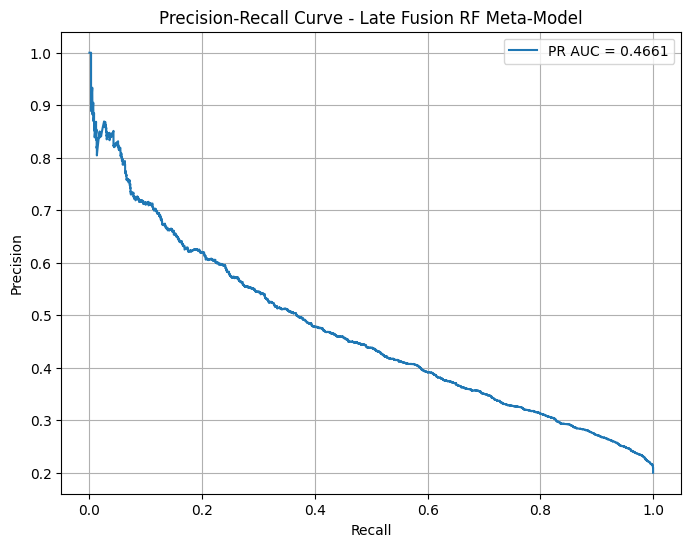

In [ ]:
import numpy as np
import json
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, precision_recall_curve, auc
)

probs_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_probs.npy")
labels_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy")

probs_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_probs.npy")
labels_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels.npy")

assert len(probs_struct) == len(probs_bert) == len(labels_struct) == len(labels_bert), "Mismatch in sizes!"
assert np.all(labels_struct == labels_bert), "Mismatch in labels!"

# Stack the probabilities together for meta-model
X_fusion = np.vstack([probs_struct, probs_bert]).T
y_fusion = labels_struct

# Train Meta-Model
meta_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
meta_clf.fit(X_fusion, y_fusion)
fused_probs = meta_clf.predict_proba(X_fusion)[:, 1]

# Threshold Tuning
precision, recall, thresholds = precision_recall_curve(y_fusion, fused_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
fused_preds = (fused_probs >= best_thresh).astype(int)

# Evaluation
auroc = roc_auc_score(y_fusion, fused_probs)
pr_auc = auc(recall, precision)

print("\n Optimized Late Fusion (Random Forest Meta-Model)")
print(f"Optimal Threshold: {best_thresh:.4f}")
print("Accuracy :", round(accuracy_score(y_fusion, fused_preds), 4))
print("Precision:", round(precision_score(y_fusion, fused_preds), 4))
print("Recall   :", round(recall_score(y_fusion, fused_preds), 4))
print("F1 Score :", round(f1_score(y_fusion, fused_preds), 4))
print("AUROC    :", round(auroc, 4))
print("PR AUC   :", round(pr_auc, 4))
print("\nClassification Report:\n", classification_report(y_fusion, fused_preds, digits=4))

# Save Outputs
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_probs.npy", fused_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_preds.npy", fused_preds)
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_labels.npy", y_fusion)
with open("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)

# Plot Precision-Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Late Fusion RF Meta-Model')
plt.legend()
plt.grid()

# Save PR Curve
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_prcurve.png")
plt.show()


In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_fusion, fused_probs)
pr_auc = auc(recall, precision)

print(f"PR AUC: {pr_auc:.4f}")


PR AUC: 0.4661


In [ ]:
import numpy as np
import json
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, precision_recall_curve
)
from sklearn.calibration import CalibratedClassifierCV

probs_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_probs.npy")
labels_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy")

probs_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_probs.npy")
labels_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels.npy")

# Stack Predictions
X_fusion = np.vstack([probs_struct, probs_bert]).T
y_fusion = labels_struct

print(f"Fusion input shape: {X_fusion.shape}")

# Train Logistic Regression Meta-Model
base_meta_model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Apply Calibration
meta_model = CalibratedClassifierCV(base_meta_model, method='sigmoid', cv='prefit')
base_meta_model.fit(X_fusion, y_fusion)
meta_model.fit(X_fusion, y_fusion)

# Predict Fused Probabilities
fused_probs = meta_model.predict_proba(X_fusion)[:, 1]

# Threshold Tuning
precision, recall, thresholds = precision_recall_curve(y_fusion, fused_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
fused_preds = (fused_probs >= best_thresh).astype(int)

# Evaluation
print(f"\nOptimized Late Fusion (Logistic Regression Meta-Model)")
print(f"Optimal Threshold: {best_thresh:.4f}")
print("Accuracy :", round(accuracy_score(y_fusion, fused_preds), 4))
print("Precision:", round(precision_score(y_fusion, fused_preds), 4))
print("Recall   :", round(recall_score(y_fusion, fused_preds), 4))
print("F1 Score :", round(f1_score(y_fusion, fused_preds), 4))
print("AUROC    :", round(roc_auc_score(y_fusion, fused_probs), 4))
print("\nClassification Report:\n", classification_report(y_fusion, fused_preds, digits=4))

# Save Outputs
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_lr_probs.npy", fused_probs)
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_lr_preds.npy", fused_preds)
np.save("/content/drive/MyDrive/FYPData/Model_Results/latefusion_lr_labels.npy", y_fusion)
with open("/content/drive/MyDrive/FYPData/Model_Results/latefusion_lr_threshold.json", "w") as f:
    json.dump({"threshold": float(best_thresh)}, f)


Fusion input shape: (14082, 2)


/usr/local/lib/python3.11/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(



Optimized Late Fusion (Logistic Regression Meta-Model)
Optimal Threshold: 0.1997
Accuracy : 0.6945
Precision: 0.3573
Recall   : 0.6611
F1 Score : 0.4639
AUROC    : 0.7459

Classification Report:
               precision    recall  f1-score   support

           0     0.8925    0.7028    0.7864     11267
           1     0.3573    0.6611    0.4639      2815

    accuracy                         0.6945     14082
   macro avg     0.6249    0.6820    0.6251     14082
weighted avg     0.7855    0.6945    0.7219     14082



# Evaluating Results

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

probs_clinicalbert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_probs_matched.npy")
labels_clinicalbert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels_matched.npy")

# Threshold
preds_clinicalbert = (probs_clinicalbert >= 0.5).astype(int)

# Compute Metrics
acc = accuracy_score(labels_clinicalbert, preds_clinicalbert)
precision = precision_score(labels_clinicalbert, preds_clinicalbert)
recall = recall_score(labels_clinicalbert, preds_clinicalbert)
f1 = f1_score(labels_clinicalbert, preds_clinicalbert)
auroc = roc_auc_score(labels_clinicalbert, probs_clinicalbert)
prauc = average_precision_score(labels_clinicalbert, probs_clinicalbert)

print(f"ClinicalBERT Fine-Tuned Performance:")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUROC: {auroc:.4f}")
print(f"PR AUC: {prauc:.4f}")


ClinicalBERT Fine-Tuned Performance:
Accuracy: 0.6589
Precision: 0.3149
Recall: 0.5121
F1 Score: 0.3899
AUROC: 0.6539
PR AUC: 0.3487


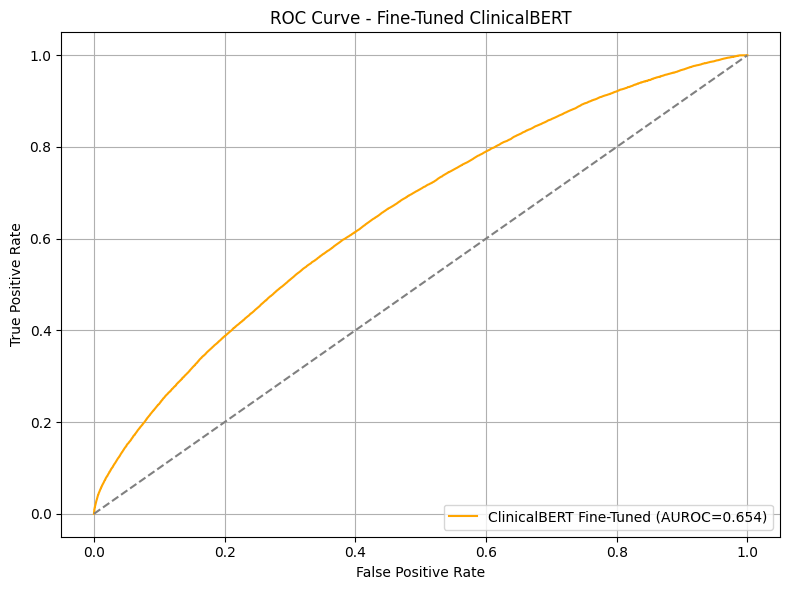

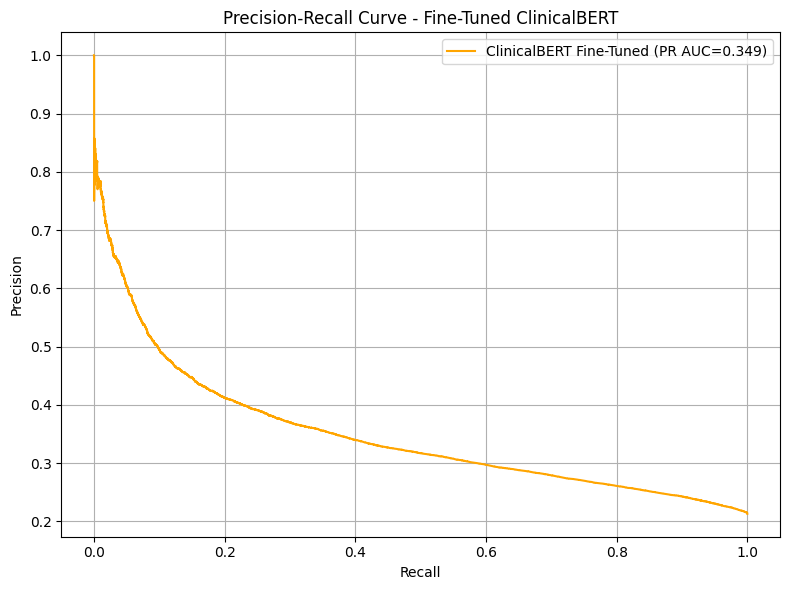

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc, roc_auc_score

probs_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_probs_matched.npy")
labels_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels_matched.npy")

# ROC Curve - ClinicalBERT
fpr, tpr, _ = roc_curve(labels_bert, probs_bert)
auroc = roc_auc_score(labels_bert, probs_bert)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='orange', label=f"ClinicalBERT Fine-Tuned (AUROC={auroc:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Fine-Tuned ClinicalBERT")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_roc_curve.png", dpi=300)
plt.show()

# PR Curve - ClinicalBERT
precision, recall, _ = precision_recall_curve(labels_bert, probs_bert)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color='orange', label=f"ClinicalBERT Fine-Tuned (PR AUC={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Fine-Tuned ClinicalBERT")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_pr_curve.png", dpi=300)
plt.show()



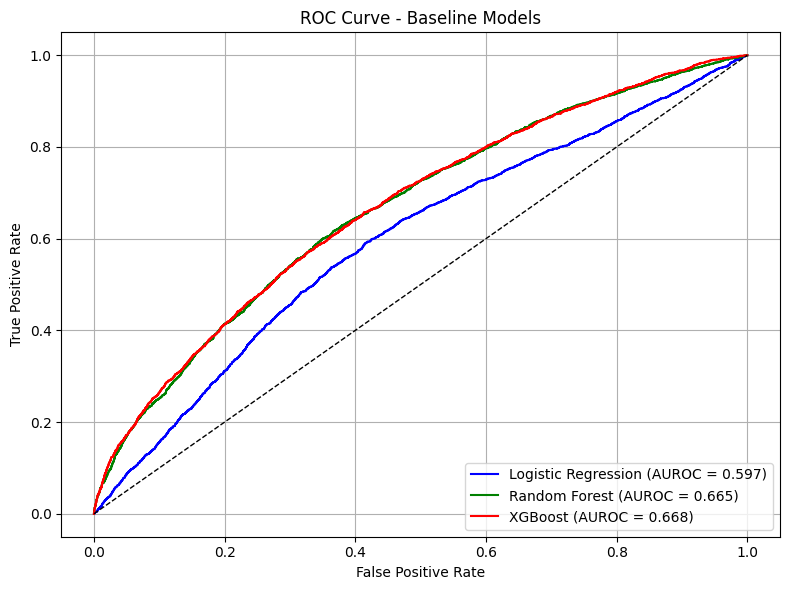

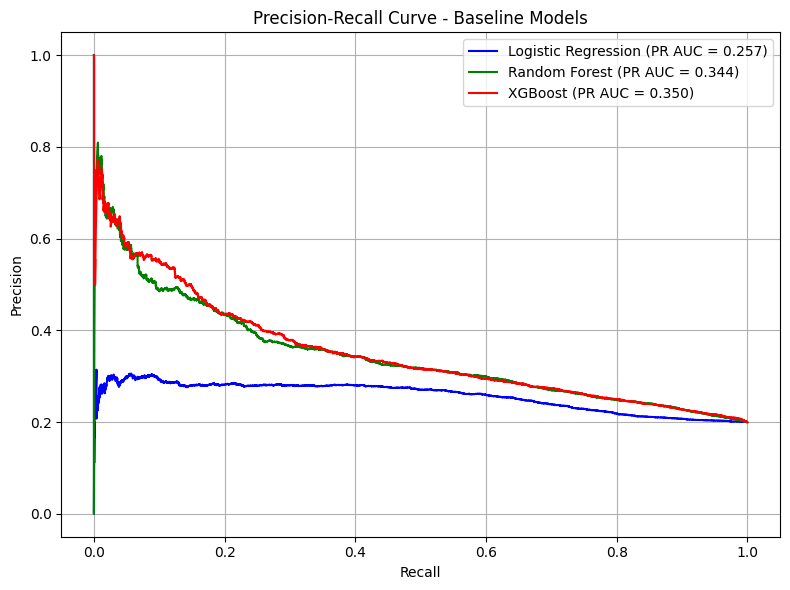

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc

probs_lr = np.load("/content/drive/MyDrive/FYPData/Model_Results/lr_test_probs.npy")
probs_rf = np.load("/content/drive/MyDrive/FYPData/Model_Results/rf_test_probs.npy")
probs_xgb = np.load("/content/drive/MyDrive/FYPData/Model_Results/xgb_test_probs.npy")
labels = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy")

# Compute Curves
fpr_lr, tpr_lr, _ = roc_curve(labels, probs_lr)
fpr_rf, tpr_rf, _ = roc_curve(labels, probs_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(labels, probs_xgb)

precision_lr, recall_lr, _ = precision_recall_curve(labels, probs_lr)
precision_rf, recall_rf, _ = precision_recall_curve(labels, probs_rf)
precision_xgb, recall_xgb, _ = precision_recall_curve(labels, probs_xgb)

# Compute AUCs
auroc_lr = auc(fpr_lr, tpr_lr)
auroc_rf = auc(fpr_rf, tpr_rf)
auroc_xgb = auc(fpr_xgb, tpr_xgb)

prauc_lr = auc(recall_lr, precision_lr)
prauc_rf = auc(recall_rf, precision_rf)
prauc_xgb = auc(recall_xgb, precision_xgb)

# ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUROC = {auroc_lr:.3f})", color='blue')
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUROC = {auroc_rf:.3f})", color='green')
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUROC = {auroc_xgb:.3f})", color='red')

plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/roc_curve_baseline_models.png")
plt.show()

# Precision-Recall Curve
plt.figure(figsize=(8,6))
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (PR AUC = {prauc_lr:.3f})", color='blue')
plt.plot(recall_rf, precision_rf, label=f"Random Forest (PR AUC = {prauc_rf:.3f})", color='green')
plt.plot(recall_xgb, precision_xgb, label=f"XGBoost (PR AUC = {prauc_xgb:.3f})", color='red')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Baseline Models')
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/pr_curve_baseline_models.png")
plt.show()



In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, classification_report, auc
)

def evaluate_model(test_probs, test_labels, model_name):
    # Threshold tuning
    precision, recall, thresholds = precision_recall_curve(test_labels, test_probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]

    # Predictions
    preds = (test_probs >= best_thresh).astype(int)

    # Metrics
    acc = accuracy_score(test_labels, preds)
    prec = precision_score(test_labels, preds)
    rec = recall_score(test_labels, preds)
    f1 = f1_score(test_labels, preds)
    auroc = roc_auc_score(test_labels, test_probs)
    pr_auc = auc(recall, precision)

    print(f"\n {model_name}")
    print(f"Optimal Threshold: {best_thresh:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUROC    : {auroc:.4f}")
    print(f"PR AUC   : {pr_auc:.4f}")
    print("Classification Report:\n", classification_report(test_labels, preds, digits=4))

    return {
        "Model": model_name,
        "Threshold": best_thresh,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1": f1,
        "AUROC": auroc,
        "PR_AUC": pr_auc
    }


# Structured MLP
probs_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_probs.npy")
labels_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy")

# ClinicalBERT MLP
probs_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_probs.npy")
labels_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels.npy")

# Late Fusion RF
probs_latefusion = np.load("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_probs.npy")
labels_latefusion = np.load("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_labels.npy")

# Hybrid Fusion MLP
probs_hybrid = np.load("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_probs.npy")
labels_hybrid = np.load("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_labels.npy")

# Evaluate all models
results = []
results.append(evaluate_model(probs_struct, labels_struct, "Structured MLP"))
results.append(evaluate_model(probs_bert, labels_bert, "ClinicalBERT MLP"))
results.append(evaluate_model(probs_latefusion, labels_latefusion, "Late Fusion RF"))
results.append(evaluate_model(probs_hybrid, labels_hybrid, "Hybrid Fusion MLP"))

# Create summary table
import pandas as pd
results_df = pd.DataFrame(results)
print("\n\Summary Table")
print(results_df)



 Structured MLP
Optimal Threshold: 0.4866
Accuracy : 0.6185
Precision: 0.2898
Recall   : 0.6263
F1 Score : 0.3963
AUROC    : 0.6656
PR AUC   : 0.3407
Classification Report:
               precision    recall  f1-score   support

           0     0.8685    0.6166    0.7212     11267
           1     0.2898    0.6263    0.3963      2815

    accuracy                         0.6185     14082
   macro avg     0.5792    0.6214    0.5587     14082
weighted avg     0.7528    0.6185    0.6562     14082


 ClinicalBERT MLP
Optimal Threshold: 0.4942
Accuracy : 0.6966
Precision: 0.3557
Recall   : 0.6384
F1 Score : 0.4568
AUROC    : 0.7418
PR AUC   : 0.4350
Classification Report:
               precision    recall  f1-score   support

           0     0.8873    0.7111    0.7895     11267
           1     0.3557    0.6384    0.4568      2815

    accuracy                         0.6966     14082
   macro avg     0.6215    0.6747    0.6232     14082
weighted avg     0.7810    0.6966    0.7230     1

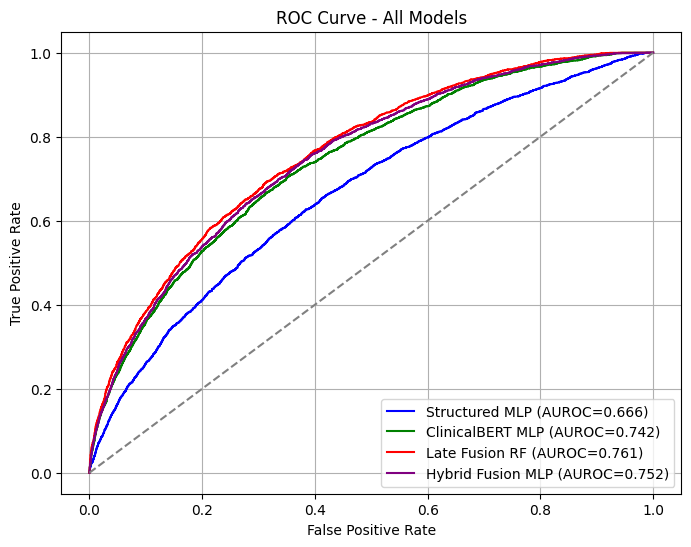

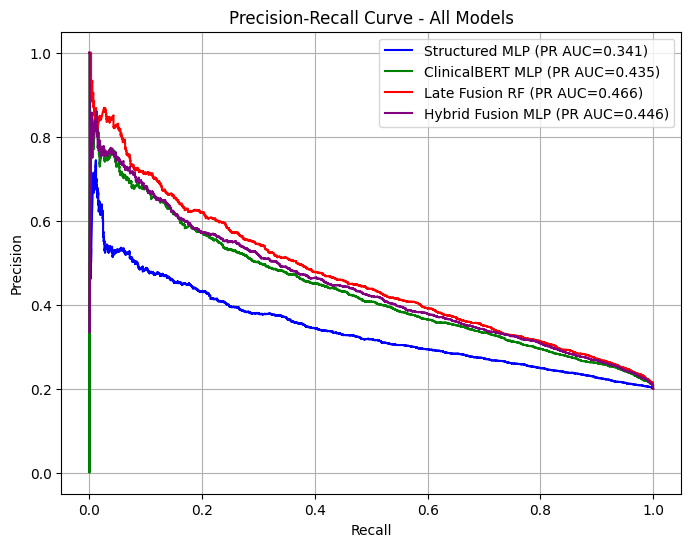

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

# Structured MLP
probs_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_probs.npy")
labels_struct = np.load("/content/drive/MyDrive/FYPData/Model_Results/structured_leakagefree_test_labels.npy")

# ClinicalBERT MLP
probs_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_probs.npy")
labels_bert = np.load("/content/drive/MyDrive/FYPData/Model_Results/clinicalbert_test_labels.npy")

# Late Fusion (Random Forest)
probs_latefusion = np.load("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_probs.npy")
labels_latefusion = np.load("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_labels.npy")

# Final Hybrid Fusion MLP
probs_hybrid = np.load("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_probs.npy")
labels_hybrid = np.load("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_test_labels.npy")

assert np.array_equal(labels_struct, labels_bert) == True
assert np.array_equal(labels_struct, labels_latefusion) == True
assert np.array_equal(labels_struct, labels_hybrid) == True

# Prepare Models to Plot
models = {
    "Structured MLP": probs_struct,
    "ClinicalBERT MLP": probs_bert,
    "Late Fusion RF": probs_latefusion,
    "Hybrid Fusion MLP": probs_hybrid,
}

colors = ["blue", "green", "red", "purple"]

# ROC Curve Plot
plt.figure(figsize=(8,6))
for (name, probs), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(labels_struct, probs)
    auroc = roc_auc_score(labels_struct, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUROC={auroc:.3f})", color=color)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All Models")
plt.legend()
plt.grid()

# Save
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/final_models_roc_curve.png", dpi=300)
plt.show()

# PR Curve Plot
plt.figure(figsize=(8,6))
for (name, probs), color in zip(models.items(), colors):
    precision, recall, _ = precision_recall_curve(labels_struct, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f"{name} (PR AUC={pr_auc:.3f})", color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - All Models")
plt.legend()
plt.grid()

# Save
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/final_models_pr_curve.png", dpi=300)
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    precision_recall_curve
)

def evaluate_model(probs_path, labels_path, model_name):
    # Load predictions and true labels
    probs = np.load(probs_path)
    labels = np.load(labels_path)

    # Find optimal threshold based on F1
    precision, recall, thresholds = precision_recall_curve(labels, probs)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    best_idx = np.argmax(f1_scores)
    best_thresh = thresholds[best_idx]
    preds = (probs >= best_thresh).astype(int)

    # Metrics
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    f1 = f1_score(labels, preds)
    auroc = roc_auc_score(labels, probs)
    pr_auc = average_precision_score(labels, probs)

    # Print results
    print(f"\n {model_name}")
    print(f"Optimal Threshold: {best_thresh:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"AUROC    : {auroc:.4f}")
    print(f"PR AUC   : {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, digits=4))

# Run for each model
evaluate_model(
    '/content/drive/MyDrive/FYPData/Model_Results/lr_test_probs.npy',
    '/content/drive/MyDrive/FYPData/Model_Results/lr_test_labels.npy',
    'Logistic Regression'
)

evaluate_model(
    '/content/drive/MyDrive/FYPData/Model_Results/rf_test_probs.npy',
    '/content/drive/MyDrive/FYPData/Model_Results/rf_test_labels.npy',
    'Random Forest'
)

evaluate_model(
    '/content/drive/MyDrive/FYPData/Model_Results/xgb_test_probs.npy',
    '/content/drive/MyDrive/FYPData/Model_Results/xgb_test_labels.npy',
    'XGBoost'
)



 Logistic Regression
Optimal Threshold: 0.4968
Accuracy : 0.5513
Precision: 0.2536
Recall   : 0.6405
F1 Score : 0.3634
AUROC    : 0.5973
PR AUC   : 0.2572

Classification Report:
              precision    recall  f1-score   support

           0     0.8549    0.5291    0.6536     11267
           1     0.2536    0.6405    0.3634      2815

    accuracy                         0.5513     14082
   macro avg     0.5542    0.5848    0.5085     14082
weighted avg     0.7347    0.5513    0.5956     14082


 Random Forest
Optimal Threshold: 0.1720
Accuracy : 0.6297
Precision: 0.2958
Recall   : 0.6174
F1 Score : 0.4000
AUROC    : 0.6655
PR AUC   : 0.3448

Classification Report:
              precision    recall  f1-score   support

           0     0.8688    0.6327    0.7322     11267
           1     0.2958    0.6174    0.4000      2815

    accuracy                         0.6297     14082
   macro avg     0.5823    0.6251    0.5661     14082
weighted avg     0.7542    0.6297    0.6658    

# XAI Methods - Interpretability

## MLP Structured

In [ ]:
import pandas as pd
import joblib
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

df = pd.read_parquet("/content/drive/MyDrive/FYPData/final_structured_aligned_with_attentionpooled.parquet")
X = df.drop(columns=['readmitted_30d', 'subject_id', 'hadm_id', 'admittime', 'dischtime', 'age_bin'])
y = df['readmitted_30d']

# Apply feature selection steps used in model
var_selector = VarianceThreshold()
X_var = var_selector.fit_transform(X)

kbest_selector = SelectKBest(f_classif, k=80)
X_selected = kbest_selector.fit_transform(X_var, y)

# First get the names after VarianceThreshold
var_support = var_selector.get_support()
X_var_df = X.loc[:, var_support]

# Then get names after SelectKBest
kbest_support = kbest_selector.get_support()
selected_feature_names = X_var_df.columns[kbest_support]

selected_feature_names = list(selected_feature_names)

# Save the feature names
joblib.dump(selected_feature_names, "/content/drive/MyDrive/FYPData/Model_Results/selected_feature_names.pkl")

print(f" Saved {len(selected_feature_names)} selected feature names.")


 Saved 80 selected feature names.


  0%|          | 0/500 [00:00<?, ?it/s]

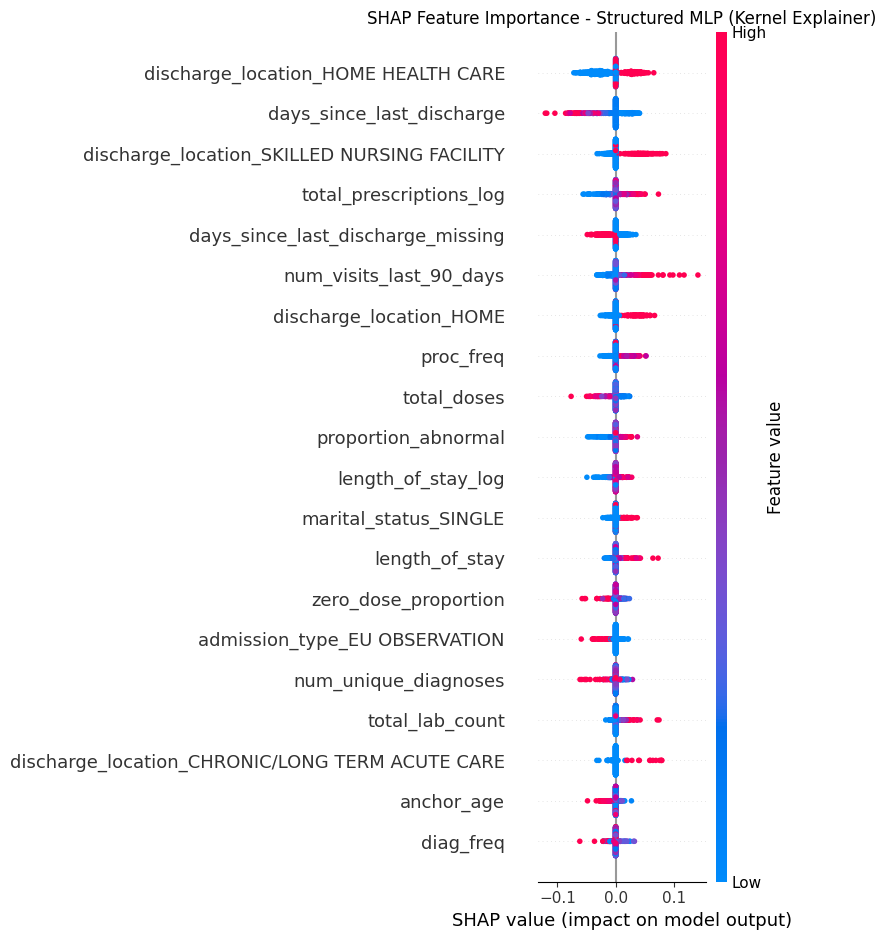

In [ ]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = StructuredMLP(input_dim=80)
base_model.load_state_dict(torch.load("/content/drive/MyDrive/FYPData/Model_Results/structured_mlp_leakagefree.pt"))
base_model = base_model.to(device)
base_model.eval()

# Define prediction function
def predict_fn(x_numpy):
    x_tensor = torch.tensor(x_numpy, dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = base_model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        return probs[:, 1].cpu().numpy()  # probability of class 1

X_full = np.load("/content/drive/MyDrive/FYPData/Model_Results/X_struct_matched_leakfree.npy")

# Background and Samples
background = X_full[:100]
X_explain = X_full[100:600]

# KernelExplainer
explainer = shap.KernelExplainer(predict_fn, background)
shap_values = explainer.shap_values(X_explain, nsamples=100)  # reduce nsamples if too slow

# Load Feature Names
try:
    feature_names = joblib.load("/content/drive/MyDrive/FYPData/Model_Results/selected_feature_names.pkl")
except:
    feature_names = [f"Feature_{i}" for i in range(X_explain.shape[1])]
    print(" Feature names not found, using generic names.")

# Plot
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, show=False)
plt.title("SHAP Feature Importance - Structured MLP (Kernel Explainer)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/shap_structured_mlp.png", dpi=300)
plt.show()




## MLP ClinicalBERT Attention Pooled Embeddings

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 128.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 136.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 108.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

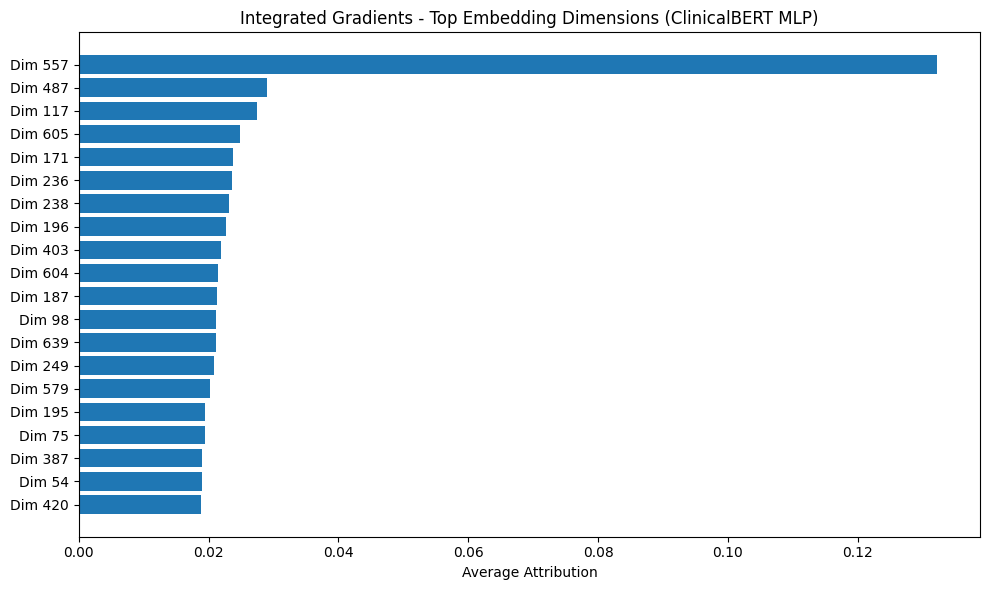

In [ ]:
!pip install captum
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ClinicalBERTMLP(input_dim=768)
model.load_state_dict(torch.load("/content/drive/MyDrive/FYPData/Model_Results/mlp_clinicalbert_optimized_final.pt"))
model = model.to(device)
model.eval()

X_full = np.load("/content/drive/MyDrive/FYPData/Model_Results/X_attentionpooled_matched.npy")
X_tensor = torch.tensor(X_full, dtype=torch.float32).to(device)

# Integrated Gradients Setup
ig = IntegratedGradients(model)

# Baseline (zero vector or mean vector)
baseline = torch.zeros_like(X_tensor[0]).unsqueeze(0)

# Select a sample to explain
X_explain = X_tensor[100:600]

# Calculate attributions
attributions, delta = ig.attribute(inputs=X_explain, baselines=baseline, target=1, return_convergence_delta=True)

# Process attributions
attr_mean = attributions.abs().mean(dim=0).cpu().detach().numpy()  # mean absolute attribution per feature

# Plot Top Features
top_indices = np.argsort(attr_mean)[::-1][:20]  # Top 20 most important dimensions

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_indices)), attr_mean[top_indices][::-1])
plt.yticks(range(len(top_indices)), [f"Dim {i}" for i in top_indices[::-1]])
plt.xlabel("Average Attribution")
plt.title("Integrated Gradients - Top Embedding Dimensions (ClinicalBERT MLP)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/ig_clinicalbert_mlp.png", dpi=300)
plt.show()


## Saliency Heatmap on Fine-Tuned ClinicalBERT on 30 Day readmission

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv')


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from transformers import AutoTokenizer, AutoModel
from IPython.core.display import display, HTML
import re

# Rebuild Architecture
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size=768):
        super().__init__()
        self.attn = nn.Parameter(torch.Tensor(hidden_size, 1))
        nn.init.xavier_uniform_(self.attn)

    def forward(self, hidden_states):
        scores = torch.matmul(hidden_states, self.attn).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        return torch.sum(weights.unsqueeze(-1) * hidden_states, dim=1)

class FinalClassifier(nn.Module):
    def __init__(self, model, hidden_size=768, num_labels=2):
        super().__init__()
        self.bert = model
        self.pool = AttentionPooling(hidden_size)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.pool(outputs.last_hidden_state)
        logits = self.classifier(pooled)
        return {"logits": logits}

# Load Saved Model and Tokenizer
save_path = "/content/drive/MyDrive/FYPData/clinicalbert_full_finalclassifier_matched"

# Load base model and tokenizer
base_model = AutoModel.from_pretrained("emilyalsentzer/Bio_ClinicalBERT")
tokenizer = AutoTokenizer.from_pretrained(save_path)

# Load full model
model = FinalClassifier(base_model)
model.load_state_dict(torch.load(f"{save_path}/pytorch_model.bin"))
model = model.cuda()
model.eval()

print(" Successfully loaded full ClinicalBERT model with attention pooling and classifier!")

# Reload cleaned notes
df = pd.read_csv("/content/drive/MyDrive/FYPData/notes_ready_for_finetuning_matched.csv")

# Clean notes
SECTION_HEADERS = [
    r"history of present illness", r"brief hospital course|hospital course",
    r"acute/active issues", r"discharge diagnosis", r"discharge condition",
    r"discharge medications", r"follow[- ]?up instructions|follow[- ]?up plan",
]

def extract_relevant_sections(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = re.sub(r'\s+', ' ', text.lower())
    relevant = []
    for i, header in enumerate(SECTION_HEADERS):
        pattern = rf"{header}.*?(?=" + "|".join(SECTION_HEADERS[i+1:] + [r"$"]) + ")"
        match = re.search(pattern, text, re.DOTALL)
        if match:
            relevant.append(match.group())
    return " ".join(relevant).strip()

def clean_text(text):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'[^a-z0-9.,;:!?()\-\'\"\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df["extracted_text"] = df["clean_text"].apply(extract_relevant_sections)
df["clean_text_sectionfiltered"] = df["extracted_text"].apply(clean_text)

# Example notes
example_texts = df["clean_text_sectionfiltered"].sample(3, random_state=42).tolist()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

 Successfully loaded full ClinicalBERT model with attention pooling and classifier!


In [ ]:
def compute_saliency(model, tokenizer, text):
    model.zero_grad()

    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=384, padding="max_length")
    inputs = {k: v.cuda() for k, v in inputs.items()}

    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    outputs = model.bert(input_ids=input_ids, attention_mask=attention_mask, output_hidden_states=True)
    hidden_states = outputs.last_hidden_state

    cls_hidden_state = hidden_states[:, 0, :]  # CLS token

    saliency_score = cls_hidden_state.sum()

    saliency_score.backward()

    grads = model.bert.embeddings.word_embeddings.weight.grad[input_ids].detach()
    grads = grads.abs().squeeze(0).sum(dim=1).detach().cpu().numpy()

    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).detach().cpu().numpy())

    return tokens, grads

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import display, HTML

# Functions
def clean_tokens(tokens):
    """Remove special tokens and artifacts from subword tokenization."""
    cleaned = []
    for token in tokens:
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        token = token.replace('##', '').replace('▁', '')
        cleaned.append(token)
    return cleaned

def plot_saliency_wrapped(tokens, saliency, save_path=None, title=None, wrap_after=20):
    """Plot saliency with token wrapping after every N tokens."""
    tokens = clean_tokens(tokens)
    saliency = saliency[:len(tokens)]

    norm_saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    cmap = plt.get_cmap('coolwarm')

    # Wrapping tokens into rows
    rows = []
    for i in range(0, len(tokens), wrap_after):
        rows.append((tokens[i:i+wrap_after], norm_saliency[i:i+wrap_after]))

    if save_path:
        fig, axs = plt.subplots(len(rows), 1, figsize=(min(wrap_after, 20), len(rows)*1.5))

        if len(rows) == 1:
            axs = [axs]

        for ax, (tokens_row, saliency_row) in zip(axs, rows):
            x = 0
            for token, score in zip(tokens_row, saliency_row):
                color = cmap(score)
                ax.text(x, 0.5, token, fontsize=9, backgroundcolor=color, ha='left', va='center')
                x += 1
            ax.set_xlim(0, x)
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

    # Also show inside notebook
    colored_text = []
    for token, weight in zip(tokens, norm_saliency):
        color = mcolors.to_hex(cmap(weight))
        colored_text.append(f"<span style='background-color:{color}'>{token}</span>")

    html_out = ''
    for i in range(0, len(colored_text), wrap_after):
        html_out += ' '.join(colored_text[i:i+wrap_after]) + '<br>'

    display(HTML(html_out))


def get_top_tokens(tokens, saliency, top_k=10):
    """Get top-k distinct important tokens after advanced cleaning."""
    tokens = clean_tokens(tokens)
    saliency = saliency[:len(tokens)]

    stopwords = set([
        "the", "a", "an", "and", "or", "in", "on", "of", "for", "with", "to", "from", "by",
        "at", "is", "was", "were", "be", "been", "he", "she", "they", "we", "you", "i",
        "his", "her", "their", "him", "them", "it", "this", "that", "as", "but", "if", "then",
        ".", ",", "-", ";", ":", "(", ")", "'", "\"",
        "however", "also", "exam", "assessment", "plan",
        "given", "past", "per", "upon", "within", "without", "under", "above", "after", "before",
        "new", "old", "baseline", "normal", "stable", "history", "previous", "reported",
        "pm", "ps", "vs", "na", "no", "non", "ed", "mr", "mrs", "ms",
        "noted", "notable", "accordingly", "there", "trace", "initial", "pertinent"
    ])

    filtered_tokens = []
    for token, sal in zip(tokens, saliency):
        token_clean = token.lower()
        if token_clean in stopwords or len(token_clean) <= 2 or token_clean.isdigit():
            continue
        filtered_tokens.append((token, sal))

    if not filtered_tokens:
        return []

    sorted_tokens = sorted(filtered_tokens, key=lambda x: abs(x[1]), reverse=True)

    seen = set()
    unique_tokens = []
    for token, score in sorted_tokens:
        token_lower = token.lower()
        if token_lower not in seen:
            seen.add(token_lower)
            unique_tokens.append((token, score))
        if len(unique_tokens) >= top_k:
            break

    return unique_tokens

def save_top_words(top_words, save_path_txt):
    """Save the top words into a text file."""
    with open(save_path_txt, 'w') as f:
        f.write("Top 10 Important Words:\n")
        for idx, (word, value) in enumerate(top_words, 1):
            f.write(f"{idx}. {word}: {value:.5f}\n")

# Pick 3 positive, long notes
example_texts = df[
    (df['readmitted_30d'] == 1) &
    (df['clean_text_sectionfiltered'].str.len() > 1000)
]["clean_text_sectionfiltered"].sample(3, random_state=123).tolist()

print(f"Picked {len(example_texts)} positive long notes for saliency.")

# Output Folder
output_dir = "/content/drive/MyDrive/FYPData/Saliency_Visualizations"
os.makedirs(output_dir, exist_ok=True)

# Full Saliency Loop
for idx, text in enumerate(example_texts):
    tokens, saliency = compute_saliency(model, tokenizer, text)

    print(f"\n Example {idx + 1}")

    # Save and display saliency
    base_path = f"{output_dir}/saliency_example_{idx+1}"
    plot_saliency_wrapped(tokens, saliency, save_path=base_path + ".png")
    print(f"Saved saliency heatmap to {base_path}.png")

    # Get and save top words
    top_words = get_top_tokens(tokens, saliency, top_k=10)
    save_top_words(top_words, save_path_txt=base_path + ".txt")
    print(f"Saved top words to {base_path}.txt")

    # Also show top words
    print("Top 10 Important Words (Most influential):")
    for i, (word, value) in enumerate(top_words, 1):
        print(f"{i}. {word}: {value:.5f}")


Picked 3 positive long notes for saliency.

 Example 1


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_1.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_1.txt
Top 10 Important Words (Most influential):
1. patient: 3.10598
2. glucose: 3.10598
3. tis: 1.84596
4. global: 1.28371
5. multiple: 1.28371
6. concern: 1.28371
7. requires: 1.28371
8. cannot: 1.28371
9. transferred: 1.28371
10. medial: 1.28371

 Example 2


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_2.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_2.txt
Top 10 Important Words (Most influential):
1. cop: 6.25170
2. family: 6.25170
3. physical: 4.59288
4. social: 4.20822
5. grave: 4.08454
6. disease: 4.08454
7. decreased: 4.08454
8. mildly: 4.08454
9. illness: 3.60953
10. developed: 3.56014

 Example 3


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_3.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_3.txt
Top 10 Important Words (Most influential):
1. patient: 10.36227
2. discharged: 10.36227
3. labs: 10.36227
4. disorder: 4.46323
5. genic: 4.43423
6. logical: 4.43423
7. ben: 4.05481
8. too: 4.05481
9. ated: 3.92850
10. evaluation: 3.59914


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.core.display import display, HTML
import numpy as np
import os

def clean_tokens(tokens):
    """Remove special tokens and artifacts like ##, ▁ from subword tokenization."""
    cleaned = []
    for token in tokens:
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue
        token = token.replace('##', '').replace('▁', '')
        cleaned.append(token)
    return cleaned

def plot_saliency_wrapped(tokens, saliency, save_path=None, title=None, wrap_after=20):
    """Plot saliency with token wrapping after every N tokens."""
    tokens = clean_tokens(tokens)
    saliency = saliency[:len(tokens)]

    norm_saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    cmap = plt.get_cmap('coolwarm')

    # Wrapping tokens into rows
    rows = []
    for i in range(0, len(tokens), wrap_after):
        rows.append((tokens[i:i+wrap_after], norm_saliency[i:i+wrap_after]))

    if save_path:
        fig, axs = plt.subplots(len(rows), 1, figsize=(min(wrap_after, 20), len(rows)*1.5))

        if len(rows) == 1:
            axs = [axs]

        for ax, (tokens_row, saliency_row) in zip(axs, rows):
            x = 0
            for token, score in zip(tokens_row, saliency_row):
                color = cmap(score)
                ax.text(x, 0.5, token, fontsize=9, backgroundcolor=color, ha='left', va='center')
                x += 1
            ax.set_xlim(0, x)
            ax.axis('off')

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.close()

    # Also show inside notebook
    colored_text = []
    for token, weight in zip(tokens, norm_saliency):
        color = mcolors.to_hex(cmap(weight))
        colored_text.append(f"<span style='background-color:{color}'>{token}</span>")

    html_out = ''
    for i in range(0, len(colored_text), wrap_after):
        html_out += ' '.join(colored_text[i:i+wrap_after]) + '<br>'

    display(HTML(html_out))

def get_top_tokens(tokens, saliency, top_k=10):
    """Get top-k distinct important tokens after advanced cleaning."""
    tokens = clean_tokens(tokens)
    saliency = saliency[:len(tokens)]

    stopwords = set([
        "the", "a", "an", "and", "or", "in", "on", "of", "for", "with", "to", "from", "by",
        "at", "is", "was", "were", "be", "been", "he", "she", "they", "we", "you", "i",
        "his", "her", "their", "him", "them", "it", "this", "that", "as", "but", "if", "then",
        ".", ",", "-", ";", ":", "(", ")", "'", "\"",
        "however", "also", "exam", "assessment", "plan",
        "given", "past", "per", "upon", "within", "without", "under", "above", "after", "before",
        "new", "old", "baseline", "normal", "stable", "history", "previous", "reported",
        "pm", "ps", "vs", "na", "no", "non", "ed", "mr", "mrs", "ms",
        "noted", "notable", "accordingly", "there", "trace", "initial", "pertinent"
    ])

    filtered_tokens = []
    for token, sal in zip(tokens, saliency):
        token_clean = token.lower()
        if token_clean in stopwords:
            continue
        if len(token_clean) <= 2:
            continue
        if token_clean.isdigit():
            continue
        filtered_tokens.append((token, sal))

    if not filtered_tokens:
        return []

    sorted_tokens = sorted(filtered_tokens, key=lambda x: abs(x[1]), reverse=True)

    seen = set()
    unique_tokens = []
    for token, score in sorted_tokens:
        token_lower = token.lower()
        if token_lower not in seen:
            seen.add(token_lower)
            unique_tokens.append((token, score))
        if len(unique_tokens) >= top_k:
            break

    return unique_tokens

# Example usage
example_texts = df[
    (df['readmitted_30d'] == 1) &
    (df['clean_text_sectionfiltered'].str.len() > 1000)
]["clean_text_sectionfiltered"].sample(3, random_state=123).tolist()

print(f"Picked {len(example_texts)} positive long notes for saliency.")

output_dir = "/content/drive/MyDrive/FYPData/Saliency_Visualizations"
os.makedirs(output_dir, exist_ok=True)

for idx, text in enumerate(example_texts):
    tokens, saliency = compute_saliency(model, tokenizer, text)

    print(f"\ Example {idx + 1}")

    # Display wrapped saliency
    plot_saliency_wrapped(tokens, saliency)

    # Save PNG
    save_path = f"{output_dir}/saliency_example_{idx+1}.png"
    plot_saliency_wrapped(tokens, saliency, save_path=save_path)
    print(f"Saved saliency heatmap to {save_path}")

    # Save Top 10 important words
    top_words = get_top_tokens(tokens, saliency, top_k=10)
    top_words_path = f"{output_dir}/saliency_example_{idx+1}.txt"
    with open(top_words_path, 'w') as f:
        for i, (word, importance) in enumerate(top_words, 1):
            f.write(f"{i}. {word}: {importance:.5f}\n")
    print(f"Saved top words to {top_words_path}")


Picked 3 positive long notes for saliency.
\ Example 1


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_1.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_1.txt
\ Example 2


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_2.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_2.txt
\ Example 3


Saved saliency heatmap to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_3.png
Saved top words to /content/drive/MyDrive/FYPData/Saliency_Visualizations/saliency_example_3.txt


## Mid Fusion Gate Attention

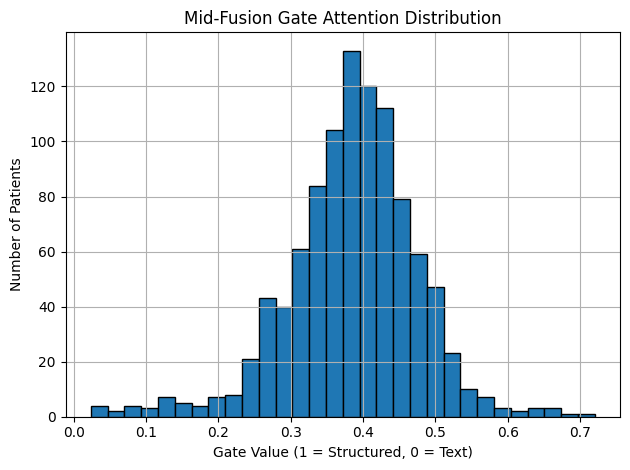

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import joblib

X_fused = np.load("/content/drive/MyDrive/FYPData/Model_Results/X_fused_struct_attentionpooled.npy")

scaler = joblib.load("/content/drive/MyDrive/FYPData/Model_Results/scaler_hybrid_attentionpooled_leakagefree.pkl")
X_fused_scaled = scaler.transform(X_fused)

# Define model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImprovedFinalFusionModel(struct_dim=X_fused.shape[1] - 768).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/FYPData/Model_Results/improved_hybrid_attentionpooled_mlp.pt"))
model.eval()

# Sample
X_sample = torch.tensor(X_fused_scaled[:1000], dtype=torch.float32).to(device)

# Compute gates
with torch.no_grad():
    struct = X_sample[:, :-768]
    text = X_sample[:, -768:]
    struct_feat = model.struct_branch(struct)
    struct_feat = model.struct_project(struct_feat)
    text_feat = model.text_branch(text)
    fusion_input = torch.cat([struct_feat, text_feat], dim=1)
    gates = torch.sigmoid(model.attn_fusion(fusion_input)).cpu().numpy()

# Plot
plt.hist(gates, bins=30, edgecolor='black')
plt.title("Mid-Fusion Gate Attention Distribution")
plt.xlabel("Gate Value (1 = Structured, 0 = Text)")
plt.ylabel("Number of Patients")
plt.grid(True)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/midfusion_gate_distribution.png", dpi=300)
plt.show()



## Late Fusion Feature Importance

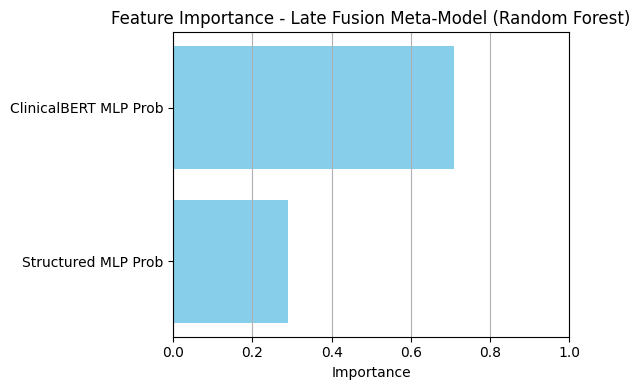

Structured MLP Prob: 0.2899
ClinicalBERT MLP Prob: 0.7101


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Feature Importances
importances = meta_clf.feature_importances_
feature_names = ["Structured MLP Prob", "ClinicalBERT MLP Prob"]

plt.figure(figsize=(6,4))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Importance")
plt.title("Feature Importance - Late Fusion Meta-Model (Random Forest)")
plt.xlim(0, 1)
plt.grid(axis='x')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/FYPData/Model_Results/latefusion_rf_feature_importance.png", dpi=300)
plt.show()

# Print values too
for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.4f}")
